# ✈️ NASA C-MAPSS FD001 — 딥러닝 모델링 (LSTM / BiLSTM / Transformer / CNN+Transformer)

**전처리 노트북(v5) 산출물(`preprocessed/dl/`) 기반 딥러닝 RUL 예측 파이프라인**

| 항목 | 내용 |
|------|------|
| 입력 데이터 | `FD001_dl_subtrain_long.csv` / `FD001_dl_valid_long.csv` / `FD001_dl_test_long.csv` |
| 윈도우 크기 | 30 사이클 (step=1, many-to-one) |
| 피처 | 유용 센서 14개 (MinMaxScaler 정규화 완료) |
| 모델 | LSTM / BiLSTM / Transformer / CNN+Transformer |
| HPO | Optuna (TPESampler) — 모델당 30 trials |
| 실험 추적 | MLflow (nested run) |
| 평가 기준 | Val NASA Score (엔진별 마지막 사이클 기준) → Val RMSE 순 |

> **주의사항 반영:** (1) val_eval = 엔진별 마지막 윈도우 추출 (2) Test zero-padding 마스킹 (3) RUL clip ≥ 0 일관 적용


## 0. 환경 설정

In [13]:
import sys, subprocess
REQUIRED = [
    'torch', 'numpy', 'pandas', 'scikit-learn',
    'matplotlib', 'seaborn', 'optuna', 'mlflow', 'joblib', 'scipy'
]
for pkg in REQUIRED:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('✅ 라이브러리 설치 완료')


✅ 라이브러리 설치 완료


In [14]:
import os, warnings, time, json, math, platform
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import optuna
import mlflow
import mlflow.pytorch
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── 한글 폰트 ──────────────────────────────────────────────────────────────────
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 다크 테마 ─────────────────────────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})

# ── 전역 상수 ─────────────────────────────────────────────────────────────────
DATA_DIR        = 'preprocessed'
DL_DIR          = os.path.join(DATA_DIR, 'dl')
RESULT_DIR      = 'results_dl'
MODEL_DIR       = 'models_dl'
MLFLOW_DIR      = 'mlruns'
EXPERIMENT_NAME = 'CMAPSS_FD001_DL'

RANDOM_STATE    = 42
WINDOW_SIZE     = 30
CLIP_LOWER      = 0.0
BATCH_SIZE      = 256
N_TRIALS        = 30     # Optuna trials (모델당)
EPOCHS_SEARCH   = 30     # Optuna 탐색 시 epoch 수
EPOCHS_FINAL    = 100    # 최적 파라미터 최종 학습 epoch 수
PATIENCE        = 10     # Early stopping patience
PRIMARY_METRIC  = 'Val NASA(eval)'
SECONDARY_METRIC= 'Val RMSE'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MODEL_COLORS = {
    'LSTM'           : C[0],
    'BiLSTM'         : C[2],
    'Transformer'    : C[1],
    'CNN+Transformer': C[3],
}
MODEL_NAMES = list(MODEL_COLORS.keys())

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(MLFLOW_DIR, exist_ok=True)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('✅ 환경 설정 완료')
print(f'   Device          : {DEVICE}')
print(f'   DATA_DIR        : {os.path.abspath(DATA_DIR)}')
print(f'   WINDOW_SIZE     : {WINDOW_SIZE}')
print(f'   BATCH_SIZE      : {BATCH_SIZE}')
print(f'   N_TRIALS        : {N_TRIALS}')
print(f'   EPOCHS_SEARCH   : {EPOCHS_SEARCH}  |  EPOCHS_FINAL: {EPOCHS_FINAL}')
print(f'   Early Stopping  : patience={PATIENCE}')


✅ 환경 설정 완료
   Device          : cuda
   DATA_DIR        : /content/preprocessed
   WINDOW_SIZE     : 30
   BATCH_SIZE      : 256
   N_TRIALS        : 30
   EPOCHS_SEARCH   : 30  |  EPOCHS_FINAL: 100
   Early Stopping  : patience=10


## 1. 데이터 로드 — Long Format 복원 및 3D 텐서 변환

| 파일 | 내용 |
|------|------|
| `FD001_dl_subtrain_long.csv` | sample_id \| timestep \| s_2…s_21 \| RUL |
| `FD001_dl_valid_long.csv`   | 동일 구조 |
| `FD001_dl_test_long.csv`    | 동일 구조 (test는 엔진별 1샘플, zero-pad 포함) |
| `FD001_ml_valid.csv`        | val_eval 재구성용 (unit_nr 포함) |

**Long Format 복원:** `groupby(sample_id)` → 3D 텐서 `(N, 30, 14)`  
**val_eval:** ML valid CSV 참조하여 엔진별 마지막 30사이클 윈도우 재구성 → NASA Score 계산 기준


=== 1. 데이터 로드 ===
DL 피처 (14개): ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']

3D 텐서 복원 완료:
  X_sub   : (14241, 30, 14)    y_sub   : (14241,)
  X_val   : (3490, 30, 14)    y_val   : (3490,)
  X_test  : (100, 30, 14)   y_test  : (100,)

val_eval (엔진별 마지막 윈도우) : (20, 30, 14)  y: (20,)
  val_eval 엔진 20대  RUL 범위: 0 ~ 0


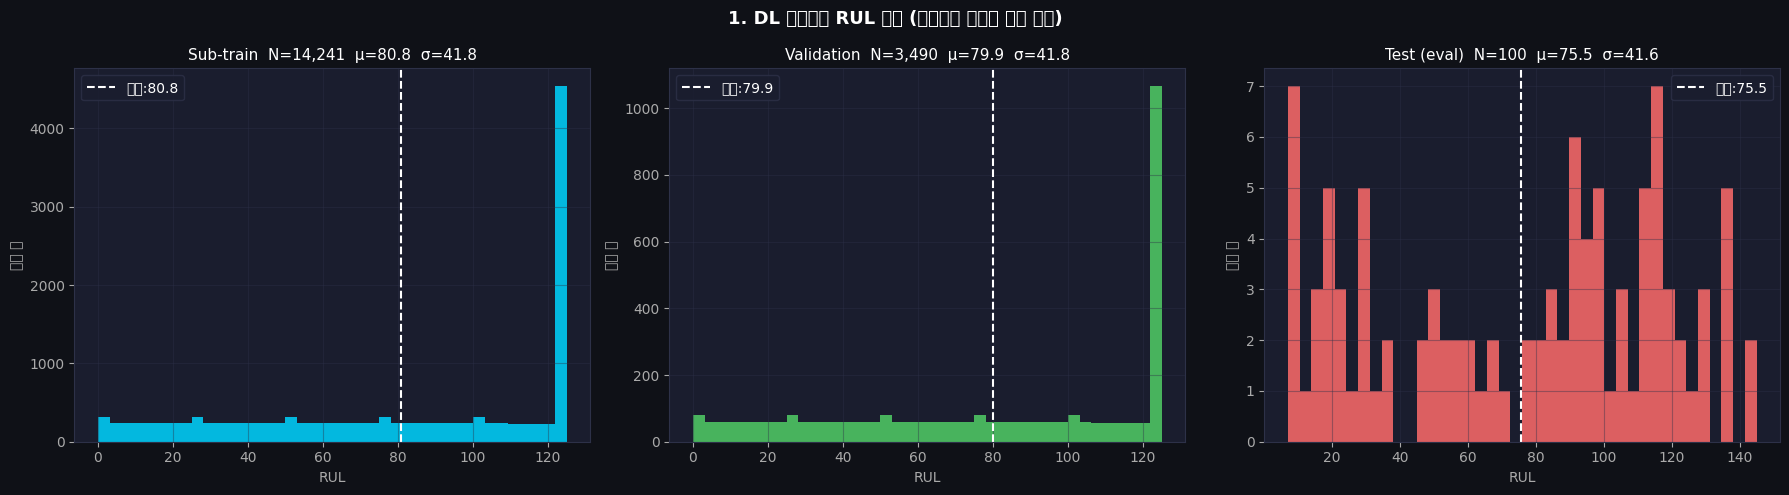


데이터 통계:
  Sub-train   : min=0  max=125  mean=80.8  std=41.8
  Validation  : min=0  max=125  mean=79.9  std=41.8
  Test        : min=7  max=145  mean=75.5  std=41.6
  Val-eval    : min=0  max=0  mean=0.0  std=0.0


In [15]:
print('=== 1. 데이터 로드 ===')

# ── DL 피처 목록 로드 ──────────────────────────────────────────────────────────
dl_feat_path = os.path.join(DATA_DIR, 'FD001_dl_features.txt')
with open(dl_feat_path, 'r', encoding='utf-8') as f:
    DL_FEATURES = [l.strip() for l in f if l.strip()]
N_FEATURES = len(DL_FEATURES)
print(f'DL 피처 ({N_FEATURES}개): {DL_FEATURES}')

# ── Long Format → 3D 텐서 복원 함수 ───────────────────────────────────────────
def load_long_format(path, feature_cols):
    """Long Format CSV → X:(n_samples, window, n_feat)  y:(n_samples,)"""
    df = pd.read_csv(path)
    df = df.sort_values(['sample_id', 'timestep']).reset_index(drop=True)
    n_samples   = df['sample_id'].nunique()
    window_size = int(df['timestep'].max()) + 1
    n_feat      = len(feature_cols)
    X = df[feature_cols].values.reshape(n_samples, window_size, n_feat).astype(np.float32)
    # RUL: 각 sample의 마지막 timestep 값 사용 (.last()로 안전하게 추출)
    y = (df.groupby('sample_id', sort=False)['RUL']
           .last().values.astype(np.float32))
    return X, y

# ── 3D 텐서 복원 ──────────────────────────────────────────────────────────────
X_sub,  y_sub  = load_long_format(os.path.join(DL_DIR, 'FD001_dl_subtrain_long.csv'), DL_FEATURES)
X_val,  y_val  = load_long_format(os.path.join(DL_DIR, 'FD001_dl_valid_long.csv'),    DL_FEATURES)
X_test, y_test = load_long_format(os.path.join(DL_DIR, 'FD001_dl_test_long.csv'),     DL_FEATURES)

print(f'\n3D 텐서 복원 완료:')
print(f'  X_sub   : {X_sub.shape}    y_sub   : {y_sub.shape}')
print(f'  X_val   : {X_val.shape}    y_val   : {y_val.shape}')
print(f'  X_test  : {X_test.shape}   y_test  : {y_test.shape}')

# ── val_eval: 엔진별 마지막 윈도우 (NASA Score 계산 기준) ─────────────────────
# ML valid CSV(unit_nr 포함)에서 엔진별 마지막 WINDOW_SIZE 사이클 추출 → Test와 동일한 방식
valid_ml = pd.read_csv(os.path.join(DATA_DIR, 'FD001_ml_valid.csv'))
rul_df   = pd.read_csv(os.path.join(DATA_DIR, 'FD001_test_RUL.csv'))

# 컬럼명 표준화
if 'unit' in valid_ml.columns and 'unit_nr' not in valid_ml.columns:
    valid_ml.rename(columns={'unit': 'unit_nr', 'cycle': 'time_cycles'}, inplace=True)

X_val_eval_list, y_val_eval_list, val_eval_units = [], [], []
for uid in np.sort(valid_ml['unit_nr'].unique()):
    udf  = valid_ml[valid_ml['unit_nr'] == uid].sort_values('time_cycles')
    data = udf[DL_FEATURES].values.astype(np.float32)
    rul  = float(udf['RUL'].iloc[-1])
    if len(data) >= WINDOW_SIZE:
        window = data[-WINDOW_SIZE:]
    else:
        pad    = np.zeros((WINDOW_SIZE - len(data), N_FEATURES), dtype=np.float32)
        window = np.vstack([pad, data])
    X_val_eval_list.append(window)
    y_val_eval_list.append(rul)
    val_eval_units.append(uid)

X_val_eval = np.array(X_val_eval_list, dtype=np.float32)
y_val_eval = np.array(y_val_eval_list, dtype=np.float32)
val_eval_units = np.array(val_eval_units)

print(f'\nval_eval (엔진별 마지막 윈도우) : {X_val_eval.shape}  y: {y_val_eval.shape}')
print(f'  val_eval 엔진 {len(val_eval_units)}대  RUL 범위: {y_val_eval.min():.0f} ~ {y_val_eval.max():.0f}')

# ── RUL 분포 시각화 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('1. DL 데이터셋 RUL 분포 (슬라이딩 윈도우 샘플 단위)', fontsize=13, fontweight='bold')

for ax, (name, y, col) in zip(axes, [
        ('Sub-train', y_sub,  C[0]),
        ('Validation', y_val, C[2]),
        ('Test (eval)', y_test, C[1])]):
    ax.hist(y, bins=40, color=col, alpha=0.85, edgecolor='none')
    ax.axvline(y.mean(), color='white', ls='--', lw=1.5, label=f'평균:{y.mean():.1f}')
    ax.set_title(f'{name}  N={len(y):,}  μ={y.mean():.1f}  σ={y.std():.1f}')
    ax.set_xlabel('RUL')
    ax.set_ylabel('샘플 수')
    ax.legend()

plt.tight_layout()
plt.show()

print('\n데이터 통계:')
for name, y in [('Sub-train', y_sub), ('Validation', y_val),
                ('Test', y_test), ('Val-eval', y_val_eval)]:
    print(f'  {name:12s}: min={y.min():.0f}  max={y.max():.0f}  '
          f'mean={y.mean():.1f}  std={y.std():.1f}')


## 2. 데이터 검증 — 무결성 체크 & 슬라이딩 윈도우 시각화

=== 2. 데이터 검증 ===
--- 데이터 무결성 ---


,shape,NaN(X),NaN(y),음수 RUL,X min,X max,y min,y max
구분,,,,,,,,
X_sub,"(14241, 30, 14)",0,0,0,0.0000,1.0000,0.0,125.0
X_val,"(3490, 30, 14)",0,0,0,-0.1094,1.0457,0.0,125.0
X_test,"(100, 30, 14)",0,0,0,-0.0288,0.9662,7.0,145.0



Test zero-padding: 0/100개 샘플 (0.0%)
  → 시계열 길이 < 30 사이클인 엔진에 앞쪽 zero-pad 적용됨
  → Transformer/LSTM의 src_key_padding_mask 또는 pack_padded_sequence로 처리 권장
  ※ FD001(단일 조건, sea level)은 대부분 30+ 사이클이므로 실제 패딩 비율은 낮음

--- 센서별 값 범위 요약 (X_sub, 정규화 후) ---


,min,max,mean,std
센서,,,,
s_2,0.0000,1.0000,0.3835,0.1465
s_3,0.0000,1.0000,0.3757,0.1307
s_4,0.0000,1.0000,0.4010,0.1537
s_7,0.0000,1.0000,0.6089,0.1592
s_8,0.0000,1.0000,0.2607,0.1128
s_9,0.0000,1.0000,0.1775,0.0861
s_11,0.0000,1.0000,0.3761,0.1657
s_12,0.0000,1.0000,0.6357,0.1578
s_13,0.0000,1.0000,0.2590,0.1178


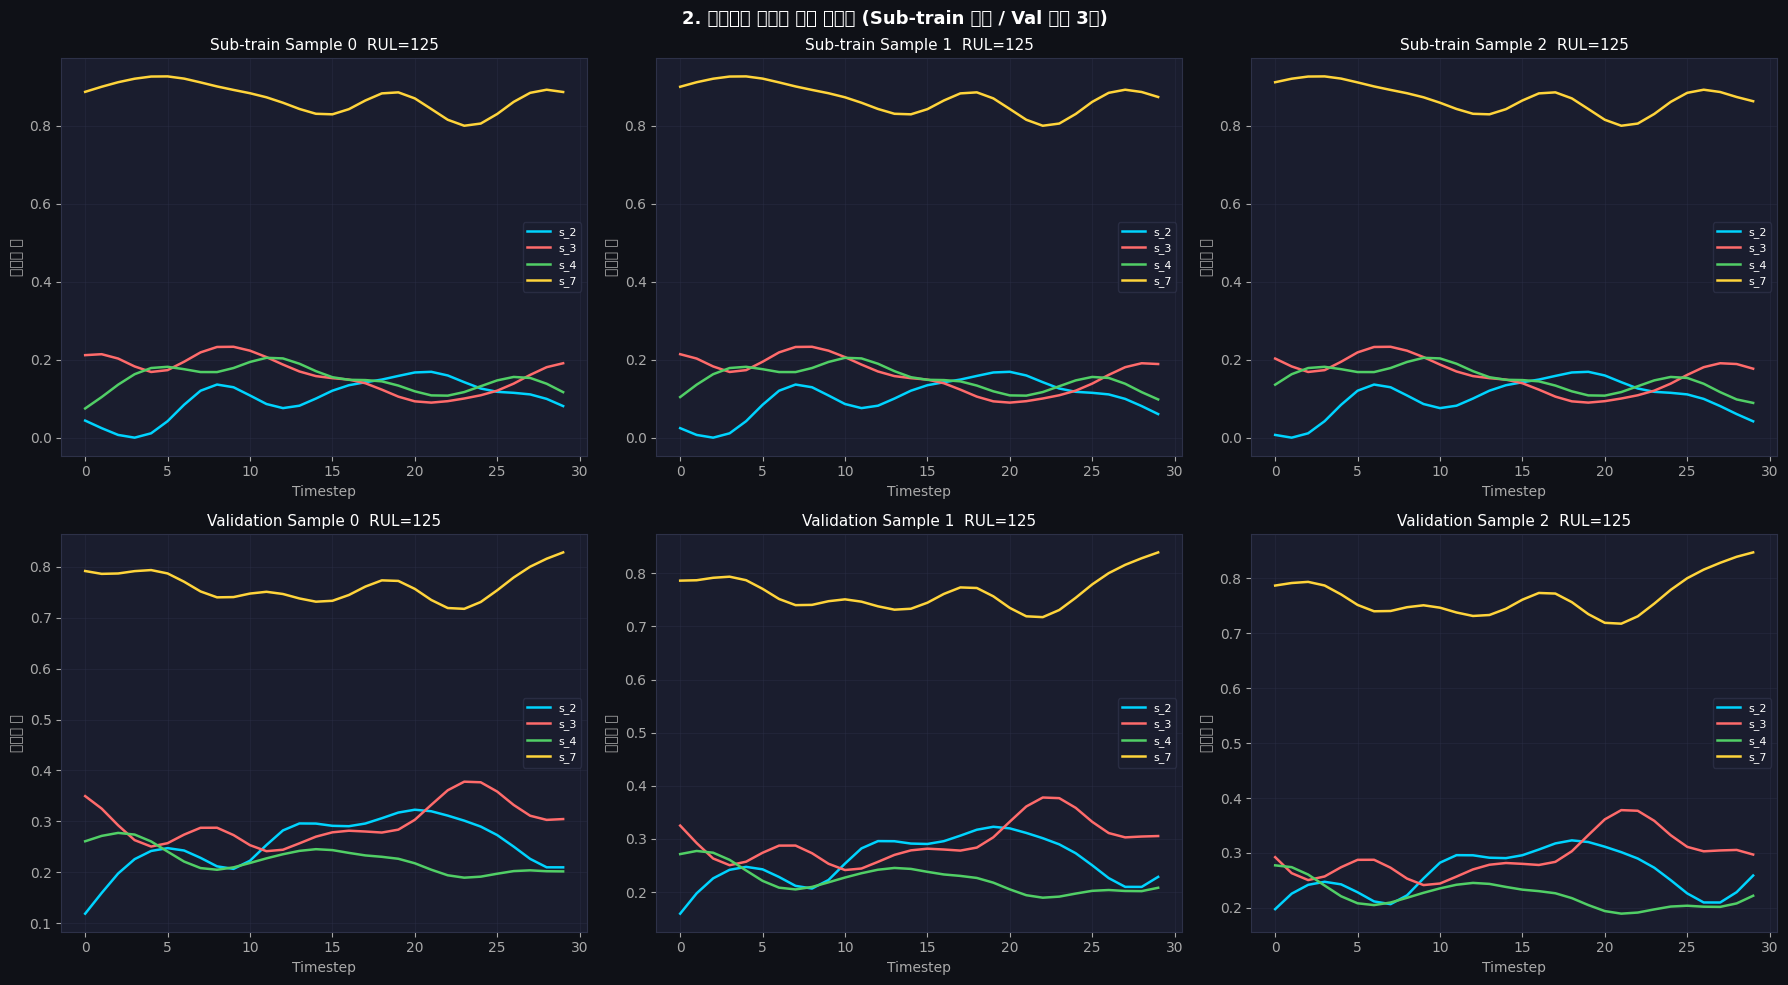

✅ 데이터 검증 완료


In [16]:
print('=== 2. 데이터 검증 ===')

# ── 무결성 검사 ───────────────────────────────────────────────────────────────
print('--- 데이터 무결성 ---')
quality_rows = []
for name, X, y in [('X_sub', X_sub, y_sub), ('X_val', X_val, y_val), ('X_test', X_test, y_test)]:
    quality_rows.append({
        '구분'       : name,
        'shape'      : str(X.shape),
        'NaN(X)'     : int(np.isnan(X).sum()),
        'NaN(y)'     : int(np.isnan(y).sum()),
        '음수 RUL'   : int((y < 0).sum()),
        'X min'      : round(float(X.min()), 4),
        'X max'      : round(float(X.max()), 4),
        'y min'      : round(float(y.min()), 1),
        'y max'      : round(float(y.max()), 1),
    })
quality_df = pd.DataFrame(quality_rows).set_index('구분')
display(quality_df)

# Test zero-padding 현황
first_ts_zero = (X_test[:, 0, :].sum(axis=1) == 0).sum()
print(f'\nTest zero-padding: {first_ts_zero}/{len(X_test)}개 샘플 ({first_ts_zero/len(X_test)*100:.1f}%)')
print('  → 시계열 길이 < 30 사이클인 엔진에 앞쪽 zero-pad 적용됨')
print('  → Transformer/LSTM의 src_key_padding_mask 또는 pack_padded_sequence로 처리 권장')
print('  ※ FD001(단일 조건, sea level)은 대부분 30+ 사이클이므로 실제 패딩 비율은 낮음')

# ── 센서 유효범위 (정규화 후 [0,1] 기대) ─────────────────────────────────────
print('\n--- 센서별 값 범위 요약 (X_sub, 정규화 후) ---')
flat_sub = X_sub.reshape(-1, N_FEATURES)
rng_df = pd.DataFrame({
    '센서'   : DL_FEATURES,
    'min'    : flat_sub.min(axis=0).round(4),
    'max'    : flat_sub.max(axis=0).round(4),
    'mean'   : flat_sub.mean(axis=0).round(4),
    'std'    : flat_sub.std(axis=0).round(4),
})
display(rng_df.set_index('센서').style.background_gradient(subset=['std'], cmap='YlOrRd').format('{:.4f}'))

# ── 윈도우 샘플 시각화 ─────────────────────────────────────────────────────────
show_feats = DL_FEATURES[:4]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('2. 슬라이딩 윈도우 샘플 시각화 (Sub-train 상위 / Val 하위 3개)',
             fontsize=13, fontweight='bold')

for ax, sidx in zip(axes[0], [0, 1, 2]):
    for fi, fn in enumerate(show_feats):
        ax.plot(X_sub[sidx, :, DL_FEATURES.index(fn)], color=C[fi], lw=1.8, label=fn)
    ax.set_title(f'Sub-train Sample {sidx}  RUL={y_sub[sidx]:.0f}')
    ax.set_xlabel('Timestep'); ax.set_ylabel('정규화 값')
    ax.legend(fontsize=8)

for ax, sidx in zip(axes[1], [0, 1, 2]):
    for fi, fn in enumerate(show_feats):
        ax.plot(X_val[sidx, :, DL_FEATURES.index(fn)], color=C[fi], lw=1.8, label=fn)
    ax.set_title(f'Validation Sample {sidx}  RUL={y_val[sidx]:.0f}')
    ax.set_xlabel('Timestep'); ax.set_ylabel('정규화 값')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
print('✅ 데이터 검증 완료')


## 3. 실험 설계 — Dataset / DataLoader, 평가 지표, 모델 정의, 학습 유틸리티

### 모델 아키텍처 요약

| 모델 | 특징 |
|------|------|
| **LSTM** | 단방향 LSTM, 마지막 hidden state → FC |
| **BiLSTM** | 양방향 LSTM, forward+backward concat → FC |
| **Transformer** | Linear projection + Positional Encoding + Encoder (Pre-LN) → CLS token → FC |
| **CNN+Transformer** | 1D-CNN 지역 특징 추출 → Transformer Encoder → FC |

- 모든 모델: gradient clipping (max_norm=1.0), RUL clip ≥ 0, Early Stopping  
- **모델 선택 기준**: Val NASA(eval) → Val RMSE (Test는 최종 확인용)


In [17]:
print('=== 3. 실험 설계 ===')

# ────────────────────────────────────────────────────────────────────────────
# PyTorch Dataset / DataLoader
# ────────────────────────────────────────────────────────────────────────────
class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def make_loaders(X_tr, y_tr, X_va, y_va, batch_size=BATCH_SIZE):
    pin = (DEVICE.type == 'cuda')
    tr = DataLoader(RULDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True,
                    num_workers=0, pin_memory=pin)
    va = DataLoader(RULDataset(X_va, y_va), batch_size=batch_size * 2, shuffle=False,
                    num_workers=0, pin_memory=pin)
    return tr, va

tr_loader, va_loader = make_loaders(X_sub, y_sub, X_val, y_val)
print(f'DataLoader 준비 완료:')
print(f'  Sub-train : {len(tr_loader.dataset):,}개 / {len(tr_loader)}배치 (batch={BATCH_SIZE})')
print(f'  Validation: {len(va_loader.dataset):,}개 / {len(va_loader)}배치')

# ────────────────────────────────────────────────────────────────────────────
# 평가 지표
# ────────────────────────────────────────────────────────────────────────────
def clip_rul(pred):
    return np.clip(np.asarray(pred, dtype=float), CLIP_LOWER, None)

def nasa_score(y_true, y_pred):
    """비대칭 NASA Score: 조기예측 페널티(÷13) < 늦은예측 페널티(÷10)"""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_rul(y_pred)
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

def get_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_rul(y_pred)
    return {
        'RMSE'      : float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE'       : float(mean_absolute_error(y_true, y_pred)),
        'R2'        : float(r2_score(y_true, y_pred)),
        'NASA_Score': float(nasa_score(y_true, y_pred)),
    }

# ────────────────────────────────────────────────────────────────────────────
# 배치 예측 (no_grad)
# ────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def predict_np(model, X_np, batch_size=512):
    model.eval()
    ds  = DataLoader(torch.tensor(X_np, dtype=torch.float32), batch_size=batch_size)
    out = []
    for xb in ds:
        out.append(model(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(out)

# ────────────────────────────────────────────────────────────────────────────
# 재현성 시드 고정
# ────────────────────────────────────────────────────────────────────────────
def set_seed(seed=RANDOM_STATE):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ────────────────────────────────────────────────────────────────────────────
# 학습 루프 (Early Stopping + LR Scheduler 내장)
# ────────────────────────────────────────────────────────────────────────────
def train_model(model, tr_loader, va_loader, optimizer, scheduler, epochs,
                patience=PATIENCE, verbose=False):
    """
    Returns
    -------
    history    : dict {'train_loss': [...], 'val_rmse': [...]}
    best_val   : float  (최저 val RMSE)
    best_epoch : int    (best epoch 번호, 1-indexed)
    """
    model.to(DEVICE)
    criterion  = nn.HuberLoss(delta=10.0)   # RUL 범위[0,125]에 맞게 delta 설정
    best_val   = float('inf')
    best_state = None
    best_epoch = 0
    wait       = 0
    history    = {'train_loss': [], 'val_rmse': []}

    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(yb)
        avg_loss = epoch_loss / len(tr_loader.dataset)

        # ── Validate ──────────────────────────────────────────────────────
        val_pred = predict_np(model, X_val)
        val_rmse = float(np.sqrt(mean_squared_error(y_val, clip_rul(val_pred))))

        if scheduler is not None:
            scheduler.step(val_rmse)

        history['train_loss'].append(avg_loss)
        history['val_rmse'].append(val_rmse)

        if verbose and epoch % 10 == 0:
            print(f'  Epoch {epoch:3d} | Loss={avg_loss:.4f} | Val RMSE={val_rmse:.4f}')

        if val_rmse < best_val - 1e-5:
            best_val   = val_rmse
            best_state = deepcopy(model.state_dict())
            best_epoch = epoch
            wait       = 0
        else:
            wait += 1
            if wait >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val, best_epoch

# ────────────────────────────────────────────────────────────────────────────
# 모델 아키텍처 정의
# ────────────────────────────────────────────────────────────────────────────

# ── Positional Encoding ───────────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=500):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

# ── LSTM ──────────────────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, fc_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, fc_size), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_size, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :])).squeeze(-1)

# ── BiLSTM ────────────────────────────────────────────────────────────────────
class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, fc_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, fc_size), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_size, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :])).squeeze(-1)

# ── Transformer ───────────────────────────────────────────────────────────────
class TransformerModel(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_layers, dim_feedforward, dropout):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_feedforward, dropout,
            batch_first=True, norm_first=True          # Pre-LN (학습 안정)
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers,
                                              norm=nn.LayerNorm(d_model))
        self.fc = nn.Sequential(
            nn.Linear(d_model, max(d_model // 2, 16)), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(d_model // 2, 16), 1)
        )

    def forward(self, x):
        x = self.pos_enc(self.input_proj(x))
        x = self.encoder(x)
        return self.fc(x[:, -1, :]).squeeze(-1)   # 마지막 타임스텝 token

# ── CNN + Transformer ────────────────────────────────────────────────────────
class CNNTransformerModel(nn.Module):
    def __init__(self, input_size, cnn_channels, kernel_size,
                 d_model, nhead, num_layers, dropout):
        super().__init__()
        # Conv1d: [B, F, T]
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, cnn_channels, kernel_size,
                      padding=kernel_size // 2, bias=False),
            nn.BatchNorm1d(cnn_channels),
            nn.GELU(),
            nn.Conv1d(cnn_channels, d_model, kernel_size,
                      padding=kernel_size // 2, bias=False),
            nn.BatchNorm1d(d_model),
            nn.GELU(),
        )
        self.pos_enc = PositionalEncoding(d_model, dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model, nhead, d_model * 2, dropout,
            batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers,
                                              norm=nn.LayerNorm(d_model))
        self.fc = nn.Sequential(
            nn.Linear(d_model, max(d_model // 2, 16)), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(max(d_model // 2, 16), 1)
        )

    def forward(self, x):
        # x: [B, T, F] → permute → CNN → permute → Transformer
        x = self.cnn(x.permute(0, 2, 1)).permute(0, 2, 1)
        x = self.pos_enc(x)
        x = self.encoder(x)
        return self.fc(x[:, -1, :]).squeeze(-1)

# ── 파라미터 수 출력 ────────────────────────────────────────────────────────────
for name, m in [
    ('LSTM (h=128, L=2)', LSTMModel(N_FEATURES, 128, 2, 0.2, 64)),
    ('BiLSTM (h=128, L=2)', BiLSTMModel(N_FEATURES, 128, 2, 0.2, 64)),
    ('Transformer (d=64, h=4, L=2)', TransformerModel(N_FEATURES, 64, 4, 2, 128, 0.1)),
    ('CNN+Transformer (d=64, h=4, L=2)', CNNTransformerModel(N_FEATURES, 64, 3, 64, 4, 2, 0.1)),
]:
    n = sum(p.numel() for p in m.parameters())
    print(f'  {name:42s}: {n:,} params')

print('\n✅ 모델 정의 및 학습 유틸리티 준비 완료')


=== 3. 실험 설계 ===
DataLoader 준비 완료:
  Sub-train : 14,241개 / 56배치 (batch=256)
  Validation: 3,490개 / 7배치
  LSTM (h=128, L=2)                         : 214,145 params
  BiLSTM (h=128, L=2)                       : 559,233 params
  Transformer (d=64, h=4, L=2)              : 70,145 params
  CNN+Transformer (d=64, h=4, L=2)          : 84,417 params

✅ 모델 정의 및 학습 유틸리티 준비 완료


## 4. MLflow 설정

In [18]:
print('=== 4. MLflow 설정 ===')

os.makedirs(MLFLOW_DIR, exist_ok=True)
tracking_uri = Path(MLFLOW_DIR).resolve().as_uri()
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(EXPERIMENT_NAME)

if mlflow.active_run() is not None:
    mlflow.end_run()

PARENT_RUN = mlflow.start_run(run_name='FD001_DL_parent')
mlflow.log_params({
    'dataset'         : 'FD001',
    'split_strategy'  : 'GroupShuffleSplit(random_state=42) — 전처리 노트북 산출물',
    'window_size'     : WINDOW_SIZE,
    'n_features'      : N_FEATURES,
    'batch_size'      : BATCH_SIZE,
    'n_trials'        : N_TRIALS,
    'epochs_search'   : EPOCHS_SEARCH,
    'epochs_final'    : EPOCHS_FINAL,
    'patience'        : PATIENCE,
    'clip_lower'      : CLIP_LOWER,
    'device'          : str(DEVICE),
    'loss_fn'         : 'HuberLoss(delta=10)',
    'optimizer'       : 'Adam',
    'lr_scheduler'    : 'ReduceLROnPlateau(patience=7, factor=0.5)',
})

print(f'Tracking URI : {mlflow.get_tracking_uri()}')
print(f'Experiment   : {EXPERIMENT_NAME}')
print(f'Parent Run ID: {PARENT_RUN.info.run_id}')
print('✅ MLflow 준비 완료')

ALL_RESULTS  = {}   # 전체 결과 저장
BEST_MODELS  = {}   # 최적 모델 저장


2026/04/22 10:30:02 INFO mlflow.tracking.fluent: Experiment with name 'CMAPSS_FD001_DL' does not exist. Creating a new experiment.


=== 4. MLflow 설정 ===
Tracking URI : file:///content/mlruns
Experiment   : CMAPSS_FD001_DL
Parent Run ID: e709c64c99cc41aa8907d29f673fc4be
✅ MLflow 준비 완료


## 5. LSTM 학습 (Optuna + MLflow)

**탐색 공간:**

| 파라미터 | 범위 |
|----------|------|
| `hidden_size` | 64, 128, 256 |
| `num_layers` | 1 ~ 3 |
| `dropout` | 0.1 ~ 0.5 |
| `fc_size` | 32, 64, 128 |
| `lr` | 1e-4 ~ 1e-2 (log) |
| `weight_decay` | 1e-6 ~ 1e-3 (log) |


=== 5. LSTM 학습 (Optuna) ===


  0%|          | 0/30 [00:00<?, ?it/s]


최적 파라미터: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2959539089646129, 'fc_size': 128, 'lr': 0.004897919406107074, 'weight_decay': 6.784087455476356e-05}
  Epoch  10 | Loss=85.6890 | Val RMSE=11.7804
  Epoch  20 | Loss=75.6047 | Val RMSE=11.9789
  Epoch  30 | Loss=74.7403 | Val RMSE=10.9854


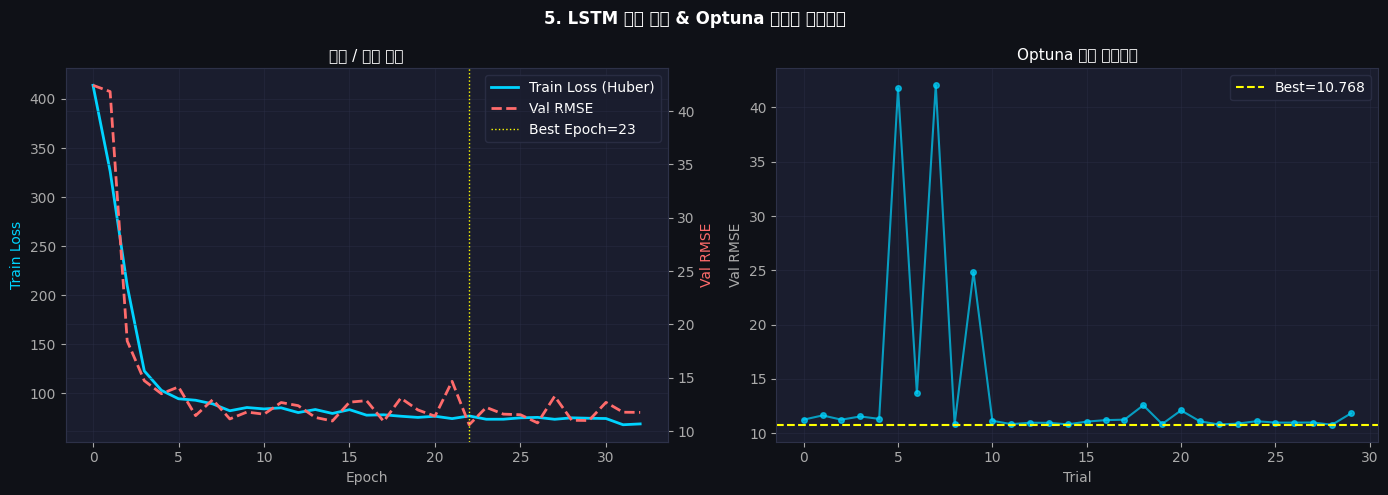


[LSTM] 완료 (18초) | Val RMSE=10.590 | Val NASA(eval)=5.4 | Test RMSE=14.863 | Test NASA=453.7 | Params=222,465


In [19]:
print('=== 5. LSTM 학습 (Optuna) ===')
MODEL_NAME = 'LSTM'

# ── Optuna 목적 함수 ──────────────────────────────────────────────────────────
best_lstm_state = {'val': float('inf'), 'state': None, 'params': None, 'trial_obj': None}

def lstm_objective(trial):
    hidden = trial.suggest_categorical('hidden_size', [64, 128, 256])
    layers = trial.suggest_int('num_layers', 1, 3)
    drop   = trial.suggest_float('dropout', 0.1, 0.5)
    fc     = trial.suggest_categorical('fc_size', [32, 64, 128])
    lr     = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd     = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    set_seed(RANDOM_STATE + trial.number)
    model = LSTMModel(N_FEATURES, hidden, layers, drop, fc).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sch   = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

    _, val_rmse, _ = train_model(model, tr_loader, va_loader, opt, sch, EPOCHS_SEARCH)

    if val_rmse < best_lstm_state['val']:
        best_lstm_state['val']      = val_rmse
        best_lstm_state['state']    = deepcopy(model.state_dict())
        best_lstm_state['params']   = trial.params
        best_lstm_state['trial_obj'] = trial

    return val_rmse

study_lstm = optuna.create_study(direction='minimize',
                                  sampler=TPESampler(seed=RANDOM_STATE),
                                  pruner=MedianPruner(n_warmup_steps=5))
study_lstm.optimize(lstm_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_p = study_lstm.best_params
print(f'\n최적 파라미터: {best_p}')

# ── 최적 파라미터로 최종 학습 ─────────────────────────────────────────────────
set_seed(RANDOM_STATE)
lstm_model = LSTMModel(N_FEATURES,
                        best_p['hidden_size'], best_p['num_layers'],
                        best_p['dropout'],     best_p['fc_size']).to(DEVICE)
opt_final = optim.Adam(lstm_model.parameters(),
                        lr=best_p['lr'], weight_decay=best_p['weight_decay'])
sch_final = optim.lr_scheduler.ReduceLROnPlateau(opt_final, patience=7, factor=0.5)

t0 = time.time()
hist_lstm, _, best_ep_lstm = train_model(
    lstm_model, tr_loader, va_loader, opt_final, sch_final, EPOCHS_FINAL, verbose=True)
elapsed_lstm = time.time() - t0

# ── 메트릭 계산 ───────────────────────────────────────────────────────────────
val_pred_lstm      = predict_np(lstm_model, X_val)
val_eval_pred_lstm = predict_np(lstm_model, X_val_eval)
test_pred_lstm     = predict_np(lstm_model, X_test)

val_metrics_lstm   = get_metrics(y_val,      val_pred_lstm)
val_eval_nasa_lstm = nasa_score(y_val_eval,  val_eval_pred_lstm)
test_metrics_lstm  = get_metrics(y_test,     test_pred_lstm)
n_params_lstm = sum(p.numel() for p in lstm_model.parameters())

ALL_RESULTS['LSTM'] = {
    'model'        : lstm_model,
    'params'       : best_p,
    'history'      : hist_lstm,
    'best_epoch'   : best_ep_lstm,
    'val_metrics'  : val_metrics_lstm,
    'val_eval_nasa': val_eval_nasa_lstm,
    'test_metrics' : test_metrics_lstm,
    'fit_seconds'  : elapsed_lstm,
    'n_params'     : n_params_lstm,
    'study'        : study_lstm,
}
BEST_MODELS['LSTM'] = lstm_model

# ── MLflow 기록 ───────────────────────────────────────────────────────────────
with mlflow.start_run(run_name='LSTM', nested=True):
    mlflow.set_tags({'model_family': 'rnn', 'model_name': 'LSTM'})
    mlflow.log_params({**best_p, 'n_params': n_params_lstm,
                       'best_epoch': best_ep_lstm, 'fit_seconds': round(elapsed_lstm,1)})
    mlflow.log_metrics({
        'val_rmse': val_metrics_lstm['RMSE'],   'val_mae': val_metrics_lstm['MAE'],
        'val_r2'  : val_metrics_lstm['R2'],     'val_nasa': val_metrics_lstm['NASA_Score'],
        'val_eval_nasa': val_eval_nasa_lstm,
        'test_rmse': test_metrics_lstm['RMSE'], 'test_mae': test_metrics_lstm['MAE'],
        'test_r2'  : test_metrics_lstm['R2'],   'test_nasa': test_metrics_lstm['NASA_Score'],
    })
    torch.save(lstm_model.state_dict(), os.path.join(MODEL_DIR, 'LSTM_best.pt'))
    mlflow.log_artifact(os.path.join(MODEL_DIR, 'LSTM_best.pt'))

# ── 학습 곡선 시각화 ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5. LSTM 학습 곡선 & Optuna 최적화 히스토리', fontsize=12, fontweight='bold')

axes[0].plot(hist_lstm['train_loss'], color=C[0], lw=2, label='Train Loss (Huber)')
ax2 = axes[0].twinx()
ax2.plot(hist_lstm['val_rmse'], color=C[1], lw=2, ls='--', label='Val RMSE')
ax2.axvline(best_ep_lstm-1, color='yellow', lw=1, ls=':', label=f'Best Epoch={best_ep_lstm}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss', color=C[0])
ax2.set_ylabel('Val RMSE', color=C[1])
axes[0].set_title('학습 / 검증 곡선'); axes[0].set_facecolor(BG2)
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1+lines2, labels1+labels2, loc='upper right')

trial_vals = [t.value for t in study_lstm.trials if t.value is not None]
axes[1].plot(trial_vals, 'o-', color=C[0], alpha=0.7, ms=4)
axes[1].axhline(study_lstm.best_value, color='yellow', lw=1.5, ls='--',
                label=f'Best={study_lstm.best_value:.3f}')
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Val RMSE')
axes[1].set_title('Optuna 탐색 히스토리'); axes[1].legend(); axes[1].set_facecolor(BG2)

plt.tight_layout(); plt.show()

print(f'\n[LSTM] 완료 ({elapsed_lstm:.0f}초) | '
      f'Val RMSE={val_metrics_lstm["RMSE"]:.3f} | '
      f'Val NASA(eval)={val_eval_nasa_lstm:.1f} | '
      f'Test RMSE={test_metrics_lstm["RMSE"]:.3f} | '
      f'Test NASA={test_metrics_lstm["NASA_Score"]:.1f} | '
      f'Params={n_params_lstm:,}')


## 6. BiLSTM 학습 (Optuna + MLflow)

LSTM과 동일한 탐색 공간, `bidirectional=True` → fc 입력 `hidden_size × 2`


=== 6. BiLSTM 학습 (Optuna) ===


  0%|          | 0/30 [00:00<?, ?it/s]


최적 파라미터: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.4935427748298675, 'fc_size': 64, 'lr': 0.0010032790020459421, 'weight_decay': 2.9815896990853394e-06}
  Epoch  10 | Loss=170.4003 | Val RMSE=19.1155
  Epoch  20 | Loss=134.6059 | Val RMSE=16.1682
  Epoch  30 | Loss=117.7944 | Val RMSE=12.4389
  Epoch  40 | Loss=107.2609 | Val RMSE=11.5130
  Epoch  50 | Loss=104.9968 | Val RMSE=11.6251


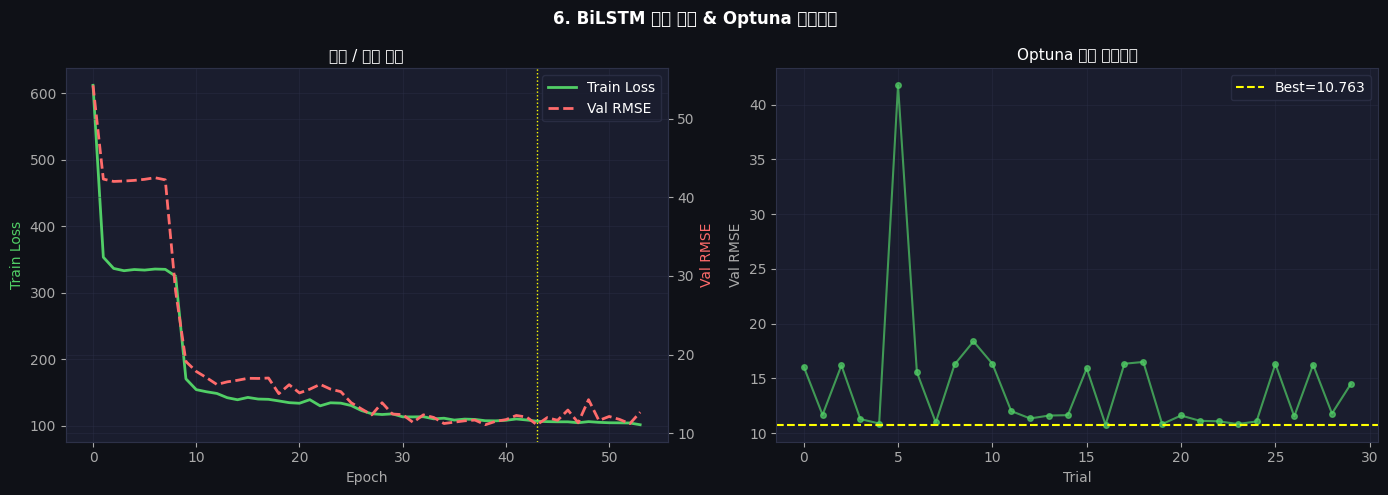


[BiLSTM] 완료 (94초) | Val RMSE=11.076 | Val NASA(eval)=4.1 | Test NASA=351.4 | Params=954,497


In [20]:
print('=== 6. BiLSTM 학습 (Optuna) ===')

best_bilstm_state = {'val': float('inf'), 'state': None, 'params': None}

def bilstm_objective(trial):
    hidden = trial.suggest_categorical('hidden_size', [64, 128, 256])
    layers = trial.suggest_int('num_layers', 1, 3)
    drop   = trial.suggest_float('dropout', 0.1, 0.5)
    fc     = trial.suggest_categorical('fc_size', [32, 64, 128])
    lr     = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd     = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    set_seed(RANDOM_STATE + trial.number)
    model = BiLSTMModel(N_FEATURES, hidden, layers, drop, fc).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sch   = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    _, val_rmse, _ = train_model(model, tr_loader, va_loader, opt, sch, EPOCHS_SEARCH)

    if val_rmse < best_bilstm_state['val']:
        best_bilstm_state.update({'val': val_rmse, 'state': deepcopy(model.state_dict()),
                                   'params': trial.params})
    return val_rmse

study_bilstm = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_bilstm.optimize(bilstm_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_p = study_bilstm.best_params
print(f'\n최적 파라미터: {best_p}')

# 최종 학습
set_seed(RANDOM_STATE)
bilstm_model = BiLSTMModel(N_FEATURES,
                            best_p['hidden_size'], best_p['num_layers'],
                            best_p['dropout'],     best_p['fc_size']).to(DEVICE)
opt_final = optim.Adam(bilstm_model.parameters(),
                        lr=best_p['lr'], weight_decay=best_p['weight_decay'])
sch_final = optim.lr_scheduler.ReduceLROnPlateau(opt_final, patience=7, factor=0.5)

t0 = time.time()
hist_bilstm, _, best_ep_bilstm = train_model(
    bilstm_model, tr_loader, va_loader, opt_final, sch_final, EPOCHS_FINAL, verbose=True)
elapsed_bilstm = time.time() - t0

val_pred_bilstm      = predict_np(bilstm_model, X_val)
val_eval_pred_bilstm = predict_np(bilstm_model, X_val_eval)
test_pred_bilstm     = predict_np(bilstm_model, X_test)

val_metrics_bilstm   = get_metrics(y_val,     val_pred_bilstm)
val_eval_nasa_bilstm = nasa_score(y_val_eval, val_eval_pred_bilstm)
test_metrics_bilstm  = get_metrics(y_test,    test_pred_bilstm)
n_params_bilstm = sum(p.numel() for p in bilstm_model.parameters())

ALL_RESULTS['BiLSTM'] = {
    'model': bilstm_model, 'params': best_p, 'history': hist_bilstm,
    'best_epoch': best_ep_bilstm, 'val_metrics': val_metrics_bilstm,
    'val_eval_nasa': val_eval_nasa_bilstm, 'test_metrics': test_metrics_bilstm,
    'fit_seconds': elapsed_bilstm, 'n_params': n_params_bilstm, 'study': study_bilstm,
}
BEST_MODELS['BiLSTM'] = bilstm_model

with mlflow.start_run(run_name='BiLSTM', nested=True):
    mlflow.set_tags({'model_family': 'rnn', 'model_name': 'BiLSTM'})
    mlflow.log_params({**best_p, 'n_params': n_params_bilstm,
                       'best_epoch': best_ep_bilstm, 'fit_seconds': round(elapsed_bilstm,1)})
    mlflow.log_metrics({
        'val_rmse': val_metrics_bilstm['RMSE'], 'val_mae': val_metrics_bilstm['MAE'],
        'val_r2': val_metrics_bilstm['R2'],     'val_nasa': val_metrics_bilstm['NASA_Score'],
        'val_eval_nasa': val_eval_nasa_bilstm,
        'test_rmse': test_metrics_bilstm['RMSE'],'test_mae': test_metrics_bilstm['MAE'],
        'test_r2': test_metrics_bilstm['R2'],    'test_nasa': test_metrics_bilstm['NASA_Score'],
    })
    torch.save(bilstm_model.state_dict(), os.path.join(MODEL_DIR, 'BiLSTM_best.pt'))
    mlflow.log_artifact(os.path.join(MODEL_DIR, 'BiLSTM_best.pt'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('6. BiLSTM 학습 곡선 & Optuna 히스토리', fontsize=12, fontweight='bold')
axes[0].plot(hist_bilstm['train_loss'], color=C[2], lw=2, label='Train Loss')
ax2 = axes[0].twinx()
ax2.plot(hist_bilstm['val_rmse'], color=C[1], lw=2, ls='--', label='Val RMSE')
ax2.axvline(best_ep_bilstm-1, color='yellow', lw=1, ls=':')
axes[0].set_facecolor(BG2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss', color=C[2])
ax2.set_ylabel('Val RMSE', color=C[1]); axes[0].set_title('학습 / 검증 곡선')
lines1,l1 = axes[0].get_legend_handles_labels(); lines2,l2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1+lines2, l1+l2, loc='upper right')

trial_vals = [t.value for t in study_bilstm.trials if t.value is not None]
axes[1].plot(trial_vals, 'o-', color=C[2], alpha=0.7, ms=4)
axes[1].axhline(study_bilstm.best_value, color='yellow', lw=1.5, ls='--',
                label=f'Best={study_bilstm.best_value:.3f}')
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Val RMSE')
axes[1].set_title('Optuna 탐색 히스토리'); axes[1].legend(); axes[1].set_facecolor(BG2)
plt.tight_layout(); plt.show()

print(f'\n[BiLSTM] 완료 ({elapsed_bilstm:.0f}초) | '
      f'Val RMSE={val_metrics_bilstm["RMSE"]:.3f} | '
      f'Val NASA(eval)={val_eval_nasa_bilstm:.1f} | '
      f'Test NASA={test_metrics_bilstm["NASA_Score"]:.1f} | '
      f'Params={n_params_bilstm:,}')


## 7. Transformer 학습 (Optuna + MLflow)

**탐색 공간:**

| 파라미터 | 범위 |
|----------|------|
| `d_model` | 64, 128 (nhead와 정합 보장) |
| `nhead` | 2, 4, 8 |
| `num_layers` | 1 ~ 4 |
| `dim_feedforward` | 64, 128, 256 |
| `dropout` | 0.1 ~ 0.4 |

Pre-LN (norm_first=True) + GELU + ADAM


=== 7. Transformer 학습 (Optuna) ===


  0%|          | 0/30 [00:00<?, ?it/s]


최적 파라미터: {'d_model': 64, 'nhead': 4, 'num_layers': 4, 'dim_feedforward': 64, 'dropout': 0.10285120945841107, 'lr': 0.001969030963380924, 'weight_decay': 7.692749611389408e-05}
  Epoch  10 | Loss=75.0092 | Val RMSE=11.7737
  Epoch  20 | Loss=71.4213 | Val RMSE=11.1883
  Epoch  30 | Loss=68.6142 | Val RMSE=12.8765


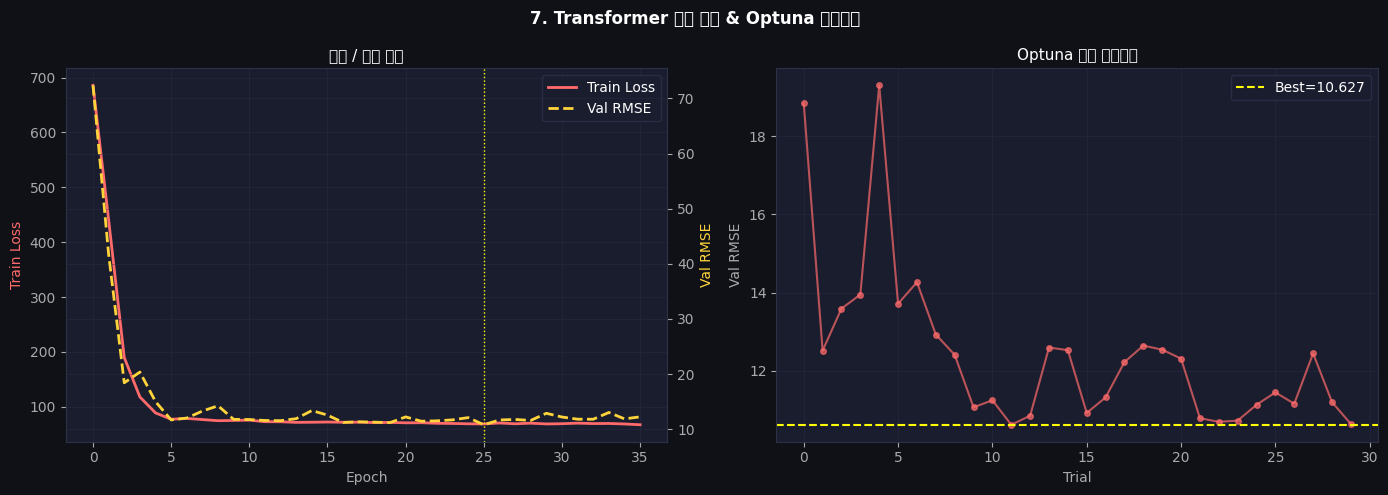


[Transformer] 완료 (34초) | Val RMSE=10.799 | Val NASA(eval)=3.8 | Test NASA=383.4 | Params=104,065


In [21]:
print('=== 7. Transformer 학습 (Optuna) ===')

best_tf_state = {'val': float('inf'), 'state': None, 'params': None}

def tf_objective(trial):
    d_model = trial.suggest_categorical('d_model', [64, 128])
    nhead   = trial.suggest_categorical('nhead', [2, 4, 8])
    if d_model % nhead != 0:   # 정합 불가 시 조기 종료
        return float('inf')
    layers  = trial.suggest_int('num_layers', 1, 4)
    dim_ff  = trial.suggest_categorical('dim_feedforward', [64, 128, 256])
    drop    = trial.suggest_float('dropout', 0.1, 0.4)
    lr      = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd      = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    set_seed(RANDOM_STATE + trial.number)
    model = TransformerModel(N_FEATURES, d_model, nhead, layers, dim_ff, drop).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sch   = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    _, val_rmse, _ = train_model(model, tr_loader, va_loader, opt, sch, EPOCHS_SEARCH)

    if val_rmse < best_tf_state['val']:
        best_tf_state.update({'val': val_rmse, 'state': deepcopy(model.state_dict()),
                               'params': trial.params})
    return val_rmse

study_tf = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_tf.optimize(tf_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_p = {k: v for k, v in study_tf.best_params.items()}
print(f'\n최적 파라미터: {best_p}')

# 최종 학습
set_seed(RANDOM_STATE)
tf_model = TransformerModel(N_FEATURES,
                             best_p['d_model'], best_p['nhead'], best_p['num_layers'],
                             best_p['dim_feedforward'], best_p['dropout']).to(DEVICE)
opt_final = optim.Adam(tf_model.parameters(),
                        lr=best_p['lr'], weight_decay=best_p['weight_decay'])
sch_final = optim.lr_scheduler.ReduceLROnPlateau(opt_final, patience=7, factor=0.5)

t0 = time.time()
hist_tf, _, best_ep_tf = train_model(
    tf_model, tr_loader, va_loader, opt_final, sch_final, EPOCHS_FINAL, verbose=True)
elapsed_tf = time.time() - t0

val_pred_tf      = predict_np(tf_model, X_val)
val_eval_pred_tf = predict_np(tf_model, X_val_eval)
test_pred_tf     = predict_np(tf_model, X_test)

val_metrics_tf   = get_metrics(y_val,     val_pred_tf)
val_eval_nasa_tf = nasa_score(y_val_eval, val_eval_pred_tf)
test_metrics_tf  = get_metrics(y_test,    test_pred_tf)
n_params_tf = sum(p.numel() for p in tf_model.parameters())

ALL_RESULTS['Transformer'] = {
    'model': tf_model, 'params': best_p, 'history': hist_tf,
    'best_epoch': best_ep_tf, 'val_metrics': val_metrics_tf,
    'val_eval_nasa': val_eval_nasa_tf, 'test_metrics': test_metrics_tf,
    'fit_seconds': elapsed_tf, 'n_params': n_params_tf, 'study': study_tf,
}
BEST_MODELS['Transformer'] = tf_model

with mlflow.start_run(run_name='Transformer', nested=True):
    mlflow.set_tags({'model_family': 'attention', 'model_name': 'Transformer'})
    mlflow.log_params({**best_p, 'n_params': n_params_tf,
                       'best_epoch': best_ep_tf, 'fit_seconds': round(elapsed_tf,1)})
    mlflow.log_metrics({
        'val_rmse': val_metrics_tf['RMSE'],   'val_mae': val_metrics_tf['MAE'],
        'val_r2': val_metrics_tf['R2'],       'val_nasa': val_metrics_tf['NASA_Score'],
        'val_eval_nasa': val_eval_nasa_tf,
        'test_rmse': test_metrics_tf['RMSE'], 'test_mae': test_metrics_tf['MAE'],
        'test_r2': test_metrics_tf['R2'],     'test_nasa': test_metrics_tf['NASA_Score'],
    })
    torch.save(tf_model.state_dict(), os.path.join(MODEL_DIR, 'Transformer_best.pt'))
    mlflow.log_artifact(os.path.join(MODEL_DIR, 'Transformer_best.pt'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('7. Transformer 학습 곡선 & Optuna 히스토리', fontsize=12, fontweight='bold')
axes[0].plot(hist_tf['train_loss'], color=C[1], lw=2, label='Train Loss')
ax2 = axes[0].twinx()
ax2.plot(hist_tf['val_rmse'], color=C[3], lw=2, ls='--', label='Val RMSE')
ax2.axvline(best_ep_tf-1, color='yellow', lw=1, ls=':')
axes[0].set_facecolor(BG2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss', color=C[1])
ax2.set_ylabel('Val RMSE', color=C[3]); axes[0].set_title('학습 / 검증 곡선')
lines1,l1 = axes[0].get_legend_handles_labels(); lines2,l2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1+lines2, l1+l2, loc='upper right')

trial_vals = [t.value for t in study_tf.trials if t.value is not None]
axes[1].plot([v for v in trial_vals if v < float('inf')], 'o-', color=C[1], alpha=0.7, ms=4)
axes[1].axhline(study_tf.best_value, color='yellow', lw=1.5, ls='--',
                label=f'Best={study_tf.best_value:.3f}')
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Val RMSE')
axes[1].set_title('Optuna 탐색 히스토리'); axes[1].legend(); axes[1].set_facecolor(BG2)
plt.tight_layout(); plt.show()

print(f'\n[Transformer] 완료 ({elapsed_tf:.0f}초) | '
      f'Val RMSE={val_metrics_tf["RMSE"]:.3f} | '
      f'Val NASA(eval)={val_eval_nasa_tf:.1f} | '
      f'Test NASA={test_metrics_tf["NASA_Score"]:.1f} | '
      f'Params={n_params_tf:,}')


## 8. CNN+Transformer 학습 (Optuna + MLflow)

**탐색 공간:**

| 파라미터 | 범위 |
|----------|------|
| `cnn_channels` | 32, 64, 128 |
| `kernel_size` | 3, 5, 7 |
| `d_model` | 64, 128 |
| `nhead` | 2, 4, 8 |
| `num_layers` | 1 ~ 3 |
| `dropout` | 0.1 ~ 0.4 |

CNN이 지역 시계열 패턴을 추출하고, Transformer가 전역 시간 의존성을 학습


=== 8. CNN+Transformer 학습 (Optuna) ===


  0%|          | 0/30 [00:00<?, ?it/s]


최적 파라미터: {'cnn_channels': 128, 'kernel_size': 3, 'd_model': 64, 'nhead': 8, 'num_layers': 3, 'dropout': 0.19402962879027197, 'lr': 0.00203588407629463, 'weight_decay': 8.20191502720173e-05}
  Epoch  10 | Loss=89.2157 | Val RMSE=14.6339


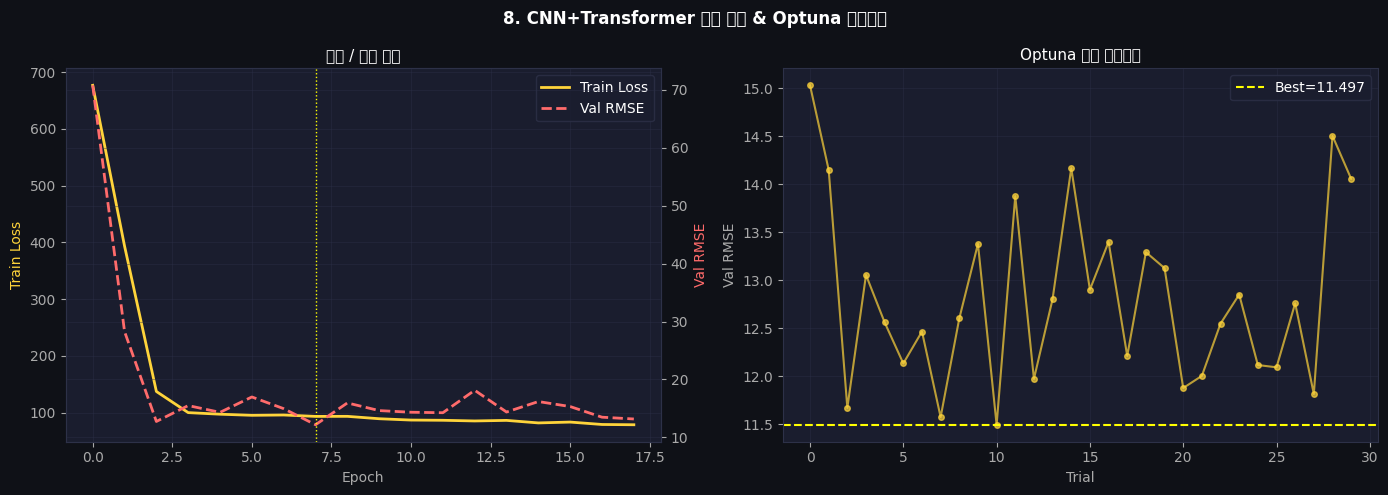


[CNN+Transformer] 완료 (19초) | Val RMSE=12.193 | Val NASA(eval)=4.5 | Test NASA=463.1 | Params=132,993


In [22]:
print('=== 8. CNN+Transformer 학습 (Optuna) ===')

best_cnntf_state = {'val': float('inf'), 'state': None, 'params': None}

def cnntf_objective(trial):
    cnn_ch  = trial.suggest_categorical('cnn_channels', [32, 64, 128])
    k_size  = trial.suggest_categorical('kernel_size', [3, 5, 7])
    d_model = trial.suggest_categorical('d_model', [64, 128])
    nhead   = trial.suggest_categorical('nhead', [2, 4, 8])
    if d_model % nhead != 0:
        return float('inf')
    layers  = trial.suggest_int('num_layers', 1, 3)
    drop    = trial.suggest_float('dropout', 0.1, 0.4)
    lr      = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd      = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)

    set_seed(RANDOM_STATE + trial.number)
    model = CNNTransformerModel(N_FEATURES, cnn_ch, k_size, d_model, nhead, layers, drop).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sch   = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    _, val_rmse, _ = train_model(model, tr_loader, va_loader, opt, sch, EPOCHS_SEARCH)

    if val_rmse < best_cnntf_state['val']:
        best_cnntf_state.update({'val': val_rmse, 'state': deepcopy(model.state_dict()),
                                  'params': trial.params})
    return val_rmse

study_cnntf = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
study_cnntf.optimize(cnntf_objective, n_trials=N_TRIALS, show_progress_bar=True)
best_p = {k: v for k, v in study_cnntf.best_params.items()}
print(f'\n최적 파라미터: {best_p}')

# 최종 학습
set_seed(RANDOM_STATE)
cnntf_model = CNNTransformerModel(
    N_FEATURES, best_p['cnn_channels'], best_p['kernel_size'],
    best_p['d_model'], best_p['nhead'], best_p['num_layers'], best_p['dropout']
).to(DEVICE)
opt_final = optim.Adam(cnntf_model.parameters(),
                        lr=best_p['lr'], weight_decay=best_p['weight_decay'])
sch_final = optim.lr_scheduler.ReduceLROnPlateau(opt_final, patience=7, factor=0.5)

t0 = time.time()
hist_cnntf, _, best_ep_cnntf = train_model(
    cnntf_model, tr_loader, va_loader, opt_final, sch_final, EPOCHS_FINAL, verbose=True)
elapsed_cnntf = time.time() - t0

val_pred_cnntf      = predict_np(cnntf_model, X_val)
val_eval_pred_cnntf = predict_np(cnntf_model, X_val_eval)
test_pred_cnntf     = predict_np(cnntf_model, X_test)

val_metrics_cnntf   = get_metrics(y_val,     val_pred_cnntf)
val_eval_nasa_cnntf = nasa_score(y_val_eval, val_eval_pred_cnntf)
test_metrics_cnntf  = get_metrics(y_test,    test_pred_cnntf)
n_params_cnntf = sum(p.numel() for p in cnntf_model.parameters())

ALL_RESULTS['CNN+Transformer'] = {
    'model': cnntf_model, 'params': best_p, 'history': hist_cnntf,
    'best_epoch': best_ep_cnntf, 'val_metrics': val_metrics_cnntf,
    'val_eval_nasa': val_eval_nasa_cnntf, 'test_metrics': test_metrics_cnntf,
    'fit_seconds': elapsed_cnntf, 'n_params': n_params_cnntf, 'study': study_cnntf,
}
BEST_MODELS['CNN+Transformer'] = cnntf_model

with mlflow.start_run(run_name='CNN+Transformer', nested=True):
    mlflow.set_tags({'model_family': 'hybrid', 'model_name': 'CNN+Transformer'})
    mlflow.log_params({**best_p, 'n_params': n_params_cnntf,
                       'best_epoch': best_ep_cnntf, 'fit_seconds': round(elapsed_cnntf,1)})
    mlflow.log_metrics({
        'val_rmse': val_metrics_cnntf['RMSE'],  'val_mae': val_metrics_cnntf['MAE'],
        'val_r2': val_metrics_cnntf['R2'],      'val_nasa': val_metrics_cnntf['NASA_Score'],
        'val_eval_nasa': val_eval_nasa_cnntf,
        'test_rmse': test_metrics_cnntf['RMSE'],'test_mae': test_metrics_cnntf['MAE'],
        'test_r2': test_metrics_cnntf['R2'],    'test_nasa': test_metrics_cnntf['NASA_Score'],
    })
    torch.save(cnntf_model.state_dict(), os.path.join(MODEL_DIR, 'CNN+Transformer_best.pt'))
    mlflow.log_artifact(os.path.join(MODEL_DIR, 'CNN+Transformer_best.pt'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('8. CNN+Transformer 학습 곡선 & Optuna 히스토리', fontsize=12, fontweight='bold')
axes[0].plot(hist_cnntf['train_loss'], color=C[3], lw=2, label='Train Loss')
ax2 = axes[0].twinx()
ax2.plot(hist_cnntf['val_rmse'], color=C[1], lw=2, ls='--', label='Val RMSE')
ax2.axvline(best_ep_cnntf-1, color='yellow', lw=1, ls=':')
axes[0].set_facecolor(BG2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss', color=C[3])
ax2.set_ylabel('Val RMSE', color=C[1]); axes[0].set_title('학습 / 검증 곡선')
lines1,l1 = axes[0].get_legend_handles_labels(); lines2,l2 = ax2.get_legend_handles_labels()
axes[0].legend(lines1+lines2, l1+l2, loc='upper right')

trial_vals = [t.value for t in study_cnntf.trials if t.value is not None]
axes[1].plot([v for v in trial_vals if v < float('inf')], 'o-', color=C[3], alpha=0.7, ms=4)
axes[1].axhline(study_cnntf.best_value, color='yellow', lw=1.5, ls='--',
                label=f'Best={study_cnntf.best_value:.3f}')
axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Val RMSE')
axes[1].set_title('Optuna 탐색 히스토리'); axes[1].legend(); axes[1].set_facecolor(BG2)
plt.tight_layout(); plt.show()

print(f'\n[CNN+Transformer] 완료 ({elapsed_cnntf:.0f}초) | '
      f'Val RMSE={val_metrics_cnntf["RMSE"]:.3f} | '
      f'Val NASA(eval)={val_eval_nasa_cnntf:.1f} | '
      f'Test NASA={test_metrics_cnntf["NASA_Score"]:.1f} | '
      f'Params={n_params_cnntf:,}')


## 9. 모델 성능 비교

> **모델 선택 기준은 Test가 아님** — Validation/NASA(eval) 중심 정렬  
> Test는 최종 일반화 성능 확인용


=== 9. 모델 성능 비교 ===


,선정순위,모델,파라미터 수,Best Epoch,Val RMSE,Val MAE,Val R²,Val NASA(eval),Test RMSE,Test MAE,Test R²,Test NASA,학습시간(초)
0,1,Transformer,"104,065",26,10.799000,7.594000,0.933100,3.8,14.895000,10.919000,0.871500,383.4,33.900000
1,2,BiLSTM,"954,497",44,11.076000,8.179000,0.929600,4.1,14.353000,10.571000,0.880700,351.4,93.500000
2,3,CNN+Transformer,"132,993",8,12.193000,8.945000,0.914700,4.5,16.157000,12.054000,0.848800,463.1,18.900000
3,4,LSTM,"222,465",23,10.590000,7.304000,0.935700,5.4,14.863000,11.021000,0.872100,453.7,18.400000



🏆 최고 모델 (Val NASA(eval) 기준): Transformer
   Val RMSE=10.799 | Val NASA(eval)=3.8 | Test RMSE=14.895 | Test NASA=383.4
📄 성능표 저장: results_dl/model_comparison_dl.csv


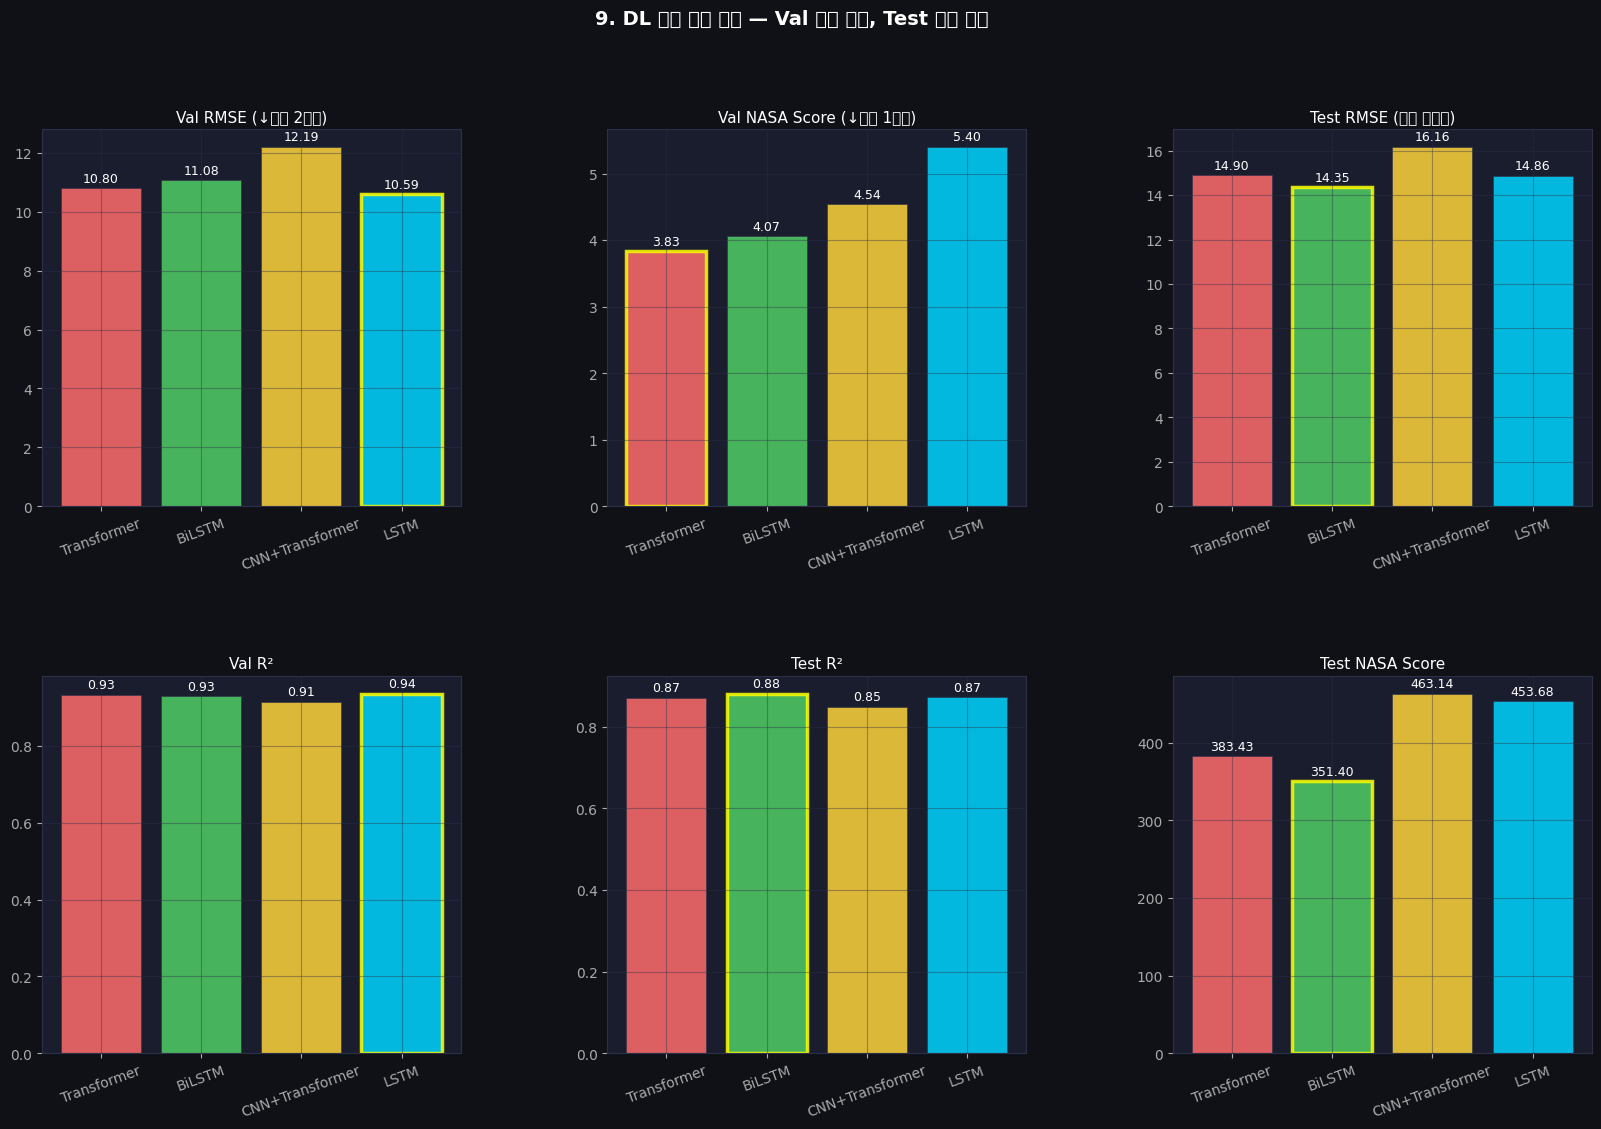

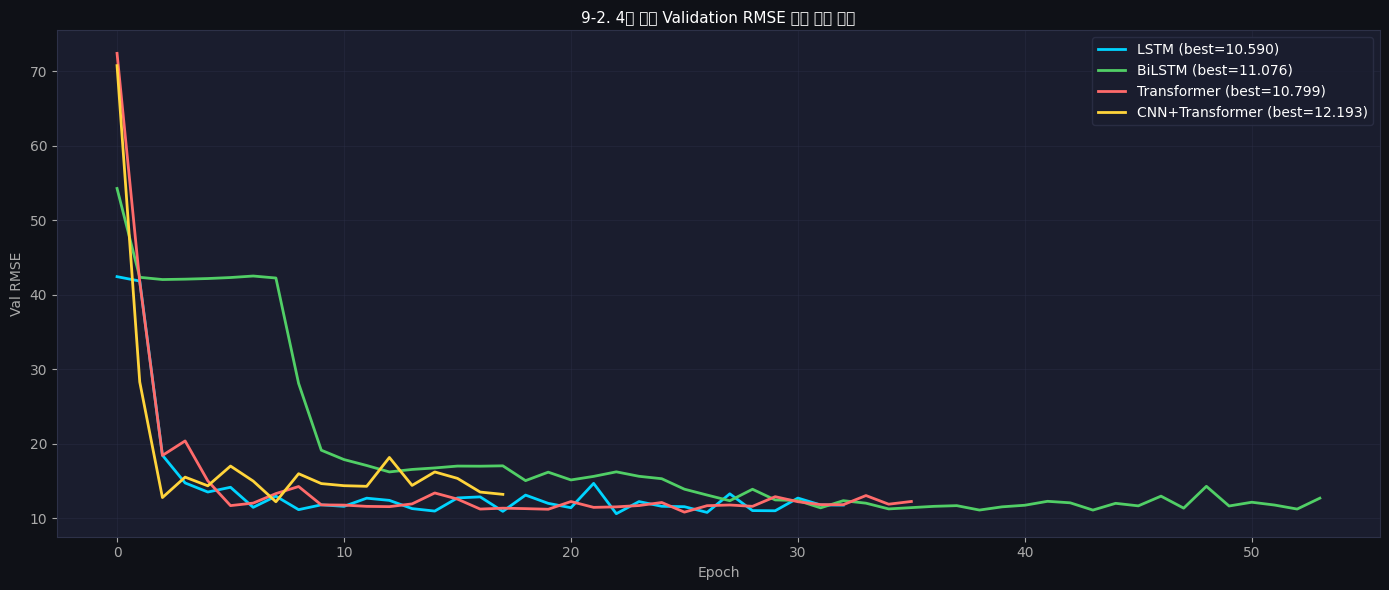

In [23]:
print('=== 9. 모델 성능 비교 ===')

rows = []
for mname, res in ALL_RESULTS.items():
    rows.append({
        '모델'           : mname,
        '파라미터 수'    : f'{res["n_params"]:,}',
        'Best Epoch'     : res['best_epoch'],
        'Val RMSE'       : round(res['val_metrics']['RMSE'], 3),
        'Val MAE'        : round(res['val_metrics']['MAE'],  3),
        'Val R²'         : round(res['val_metrics']['R2'],   4),
        'Val NASA(eval)' : round(res['val_eval_nasa'],       1),
        'Test RMSE'      : round(res['test_metrics']['RMSE'],3),
        'Test MAE'       : round(res['test_metrics']['MAE'], 3),
        'Test R²'        : round(res['test_metrics']['R2'],  4),
        'Test NASA'      : round(res['test_metrics']['NASA_Score'], 1),
        '학습시간(초)'   : round(res['fit_seconds'], 1),
    })

result_df = pd.DataFrame(rows)
result_df = result_df.sort_values('Val NASA(eval)').reset_index(drop=True)
result_df['선정순위'] = np.arange(1, len(result_df) + 1)

display_cols = ['선정순위','모델','파라미터 수','Best Epoch',
                'Val RMSE','Val MAE','Val R²','Val NASA(eval)',
                'Test RMSE','Test MAE','Test R²','Test NASA','학습시간(초)']
display(result_df[display_cols]
        .style
        .background_gradient(subset=['Val NASA(eval)','Val RMSE','Test NASA','Test RMSE'],
                             cmap='RdYlGn_r')
        .background_gradient(subset=['Val R²','Test R²'], cmap='RdYlGn')
        .format({c: '{:.3f}' for c in ['Val RMSE','Val MAE','Val R²',
                                        'Test RMSE','Test MAE','Test R²']})
        .format({'Val NASA(eval)': '{:.1f}', 'Test NASA': '{:.1f}'}))

best_model_name = result_df.iloc[0]['모델']
best_res = ALL_RESULTS[best_model_name]
print(f'\n🏆 최고 모델 (Val NASA(eval) 기준): {best_model_name}')
print(f'   Val RMSE={best_res["val_metrics"]["RMSE"]:.3f} | '
      f'Val NASA(eval)={best_res["val_eval_nasa"]:.1f} | '
      f'Test RMSE={best_res["test_metrics"]["RMSE"]:.3f} | '
      f'Test NASA={best_res["test_metrics"]["NASA_Score"]:.1f}')

result_csv_path = os.path.join(RESULT_DIR, 'model_comparison_dl.csv')
result_df[display_cols].to_csv(result_csv_path, index=False, encoding='utf-8-sig')
print(f'📄 성능표 저장: {result_csv_path}')

# ── 6-지표 비교 막대 그래프 ─────────────────────────────────────────────────
model_names   = [r['모델'] for _, r in result_df.iterrows()]
colors_bar    = [MODEL_COLORS[m] for m in model_names]

metrics_cfg = [
    ('Val RMSE',        'val_metrics.RMSE',         True,  'Val RMSE (↓선정 2순위)'),
    ('Val NASA(eval)',  'val_eval_nasa',             True,  'Val NASA Score (↓선정 1순위)'),
    ('Test RMSE',       'test_metrics.RMSE',         True,  'Test RMSE (최종 확인용)'),
    ('Val R²',          'val_metrics.R2',            False, 'Val R²'),
    ('Test R²',         'test_metrics.R2',           False, 'Test R²'),
    ('Test NASA',       'test_metrics.NASA_Score',   True,  'Test NASA Score'),
]

def get_val(res, key):
    if '.' in key:
        a, b = key.split('.'); return res[a][b]
    return res[key]

fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle('9. DL 모델 성능 비교 — Val 기준 선택, Test 최종 확인', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

for idx, (_, key, lower_better, title) in enumerate(metrics_cfg):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    vals = [get_val(ALL_RESULTS[m], key) for m in model_names]
    bars = ax.bar(model_names, vals, color=colors_bar, alpha=0.85,
                  edgecolor=GRID, linewidth=0.5)
    best_i = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[best_i].set_edgecolor('yellow'); bars[best_i].set_linewidth(2.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, color=WHITE)
    ax.set_title(title); ax.tick_params(axis='x', rotation=20)
    ax.set_facecolor(BG2)

plt.tight_layout(); plt.show()

# ── 학습 곡선 4개 모델 비교 ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
for mname, res in ALL_RESULTS.items():
    ax.plot(res['history']['val_rmse'], color=MODEL_COLORS[mname],
            lw=2, label=f'{mname} (best={res["val_metrics"]["RMSE"]:.3f})')
ax.set_title('9-2. 4개 모델 Validation RMSE 학습 곡선 비교')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val RMSE')
ax.legend(); ax.set_facecolor(BG2)
plt.tight_layout(); plt.show()


## 10. Test 세트 상세 평가 — 엔진 100대 마지막 사이클

=== 10. Test 세트 상세 평가 ===


,unit_nr,actual_RUL,LSTM_pred,LSTM_err,BiLSTM_pred,BiLSTM_err,Transformer_pred,Transformer_err,CNN+Transformer_pred,CNN+Transformer_err
0,1,112,122.5,10.5,118.1,6.1,121.3,9.3,121.5,9.5
1,2,98,125.6,27.6,119.7,21.7,122.2,24.2,121.3,23.3
2,3,69,56.4,-12.6,48.2,-20.8,55.5,-13.5,47.7,-21.3
3,4,82,80.8,-1.2,92.4,10.4,91.6,9.6,87.6,5.6
4,5,91,110.2,19.2,113.9,22.9,116.8,25.8,117.6,26.6
5,6,93,115.6,22.6,115.6,22.6,118.6,25.6,120.6,27.6
6,7,91,100.7,9.7,108.4,17.4,98.7,7.7,107.2,16.2
7,8,95,84.9,-10.1,101.4,6.4,88.7,-6.3,101.4,6.4
8,9,111,121.3,10.3,118.4,7.4,118.8,7.8,120.5,9.5
9,10,96,85.9,-10.1,94.2,-1.8,82.8,-13.2,101.0,5.0


,평균 오차(bias),오차 표준편차,조기예측 비율,늦은예측 비율,|오차|≤10 비율,|오차|≤20 비율
모델,,,,,,
LSTM,2.78,14.60,42.0%,58.0%,55.0%,84.0%
BiLSTM,1.32,14.29,47.0%,53.0%,59.0%,83.0%
Transformer,0.26,14.89,49.0%,51.0%,60.0%,85.0%
CNN+Transformer,0.51,16.15,49.0%,51.0%,58.0%,82.0%


📄 엔진별 test 예측 저장: results_dl/test_engine_predictions_dl.csv


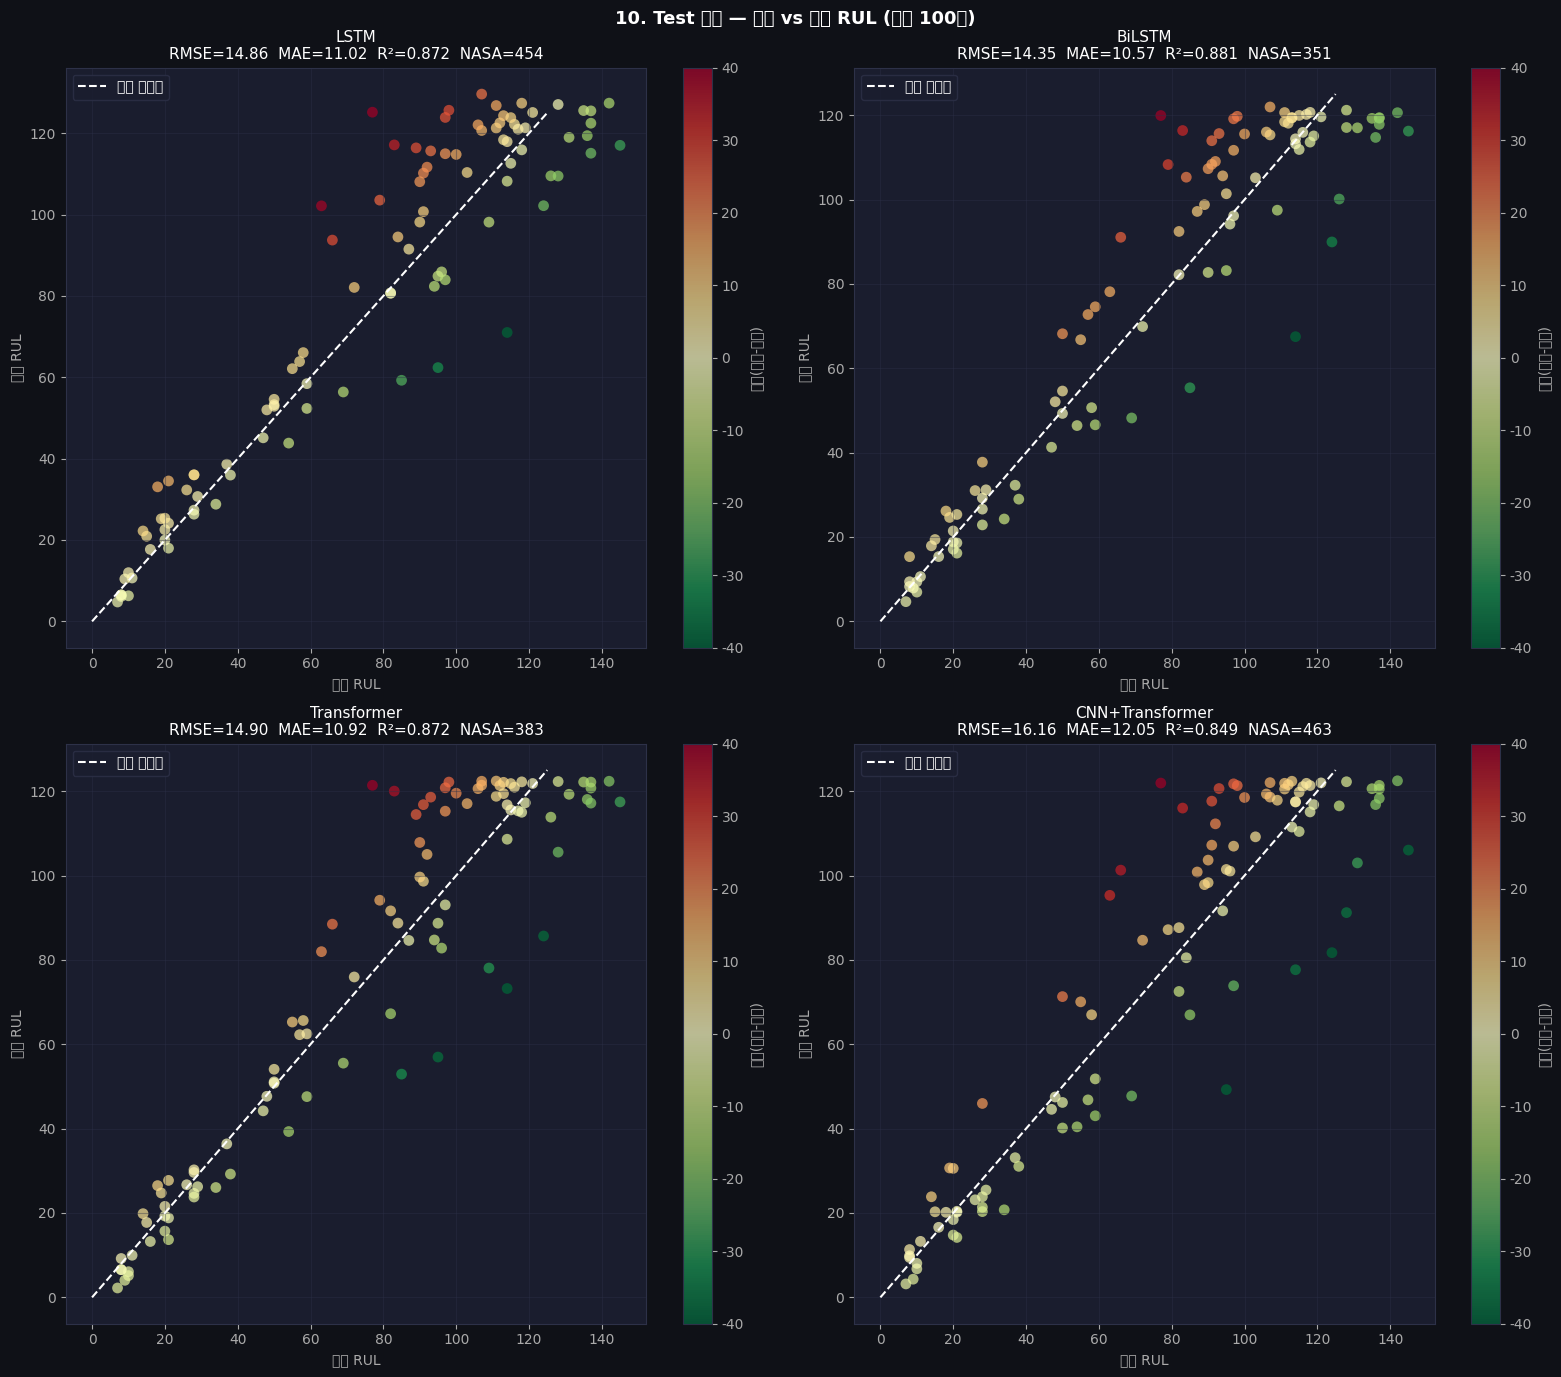

In [24]:
print('=== 10. Test 세트 상세 평가 ===')

test_pred_all = {m: clip_rul(predict_np(BEST_MODELS[m], X_test)) for m in MODEL_NAMES}

test_detail = pd.DataFrame({'unit_nr': np.arange(1, len(y_test)+1),
                             'actual_RUL': y_test.astype(int)})
for m, pred in test_pred_all.items():
    test_detail[f'{m}_pred'] = np.round(pred, 1)
    test_detail[f'{m}_err' ] = np.round(pred - y_test, 1)

display(test_detail.head(20))

# 오차 요약
err_rows = []
for mname, pred in test_pred_all.items():
    errs = pred - y_test
    err_rows.append({
        '모델'           : mname,
        '평균 오차(bias)': round(errs.mean(), 2),
        '오차 표준편차'  : round(errs.std(), 2),
        '조기예측 비율'  : f'{(errs < 0).mean()*100:.1f}%',
        '늦은예측 비율'  : f'{(errs > 0).mean()*100:.1f}%',
        '|오차|≤10 비율' : f'{(np.abs(errs) <= 10).mean()*100:.1f}%',
        '|오차|≤20 비율' : f'{(np.abs(errs) <= 20).mean()*100:.1f}%',
    })
err_df = pd.DataFrame(err_rows).set_index('모델')
display(err_df)

test_detail_path = os.path.join(RESULT_DIR, 'test_engine_predictions_dl.csv')
test_detail.to_csv(test_detail_path, index=False, encoding='utf-8-sig')
print(f'📄 엔진별 test 예측 저장: {test_detail_path}')

# 4개 모델 실제 vs 예측 scatter
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('10. Test 세트 — 실제 vs 예측 RUL (엔진 100대)', fontsize=13, fontweight='bold')

for ax, mname in zip(axes.flat, MODEL_NAMES):
    pred = test_pred_all[mname]
    err  = pred - y_test
    sc   = ax.scatter(y_test, pred, c=err, cmap='RdYlGn_r', alpha=0.7, s=60,
                      vmin=-40, vmax=40, edgecolors='none')
    ax.plot([0, 125], [0, 125], color='white', lw=1.5, ls='--', label='완벽 예측선')
    m = get_metrics(y_test, pred)
    ax.set_title(f'{mname}\nRMSE={m["RMSE"]:.2f}  MAE={m["MAE"]:.2f}  '
                 f'R²={m["R2"]:.3f}  NASA={m["NASA_Score"]:.0f}')
    ax.set_xlabel('실제 RUL'); ax.set_ylabel('예측 RUL')
    ax.legend(loc='upper left'); ax.set_facecolor(BG2)
    plt.colorbar(sc, ax=ax, label='잔차(예측-실제)')

plt.tight_layout(); plt.show()


## 11. 잔차 분석 — Validation 구간별 오차 패턴

=== 11. 잔차 분석 ===


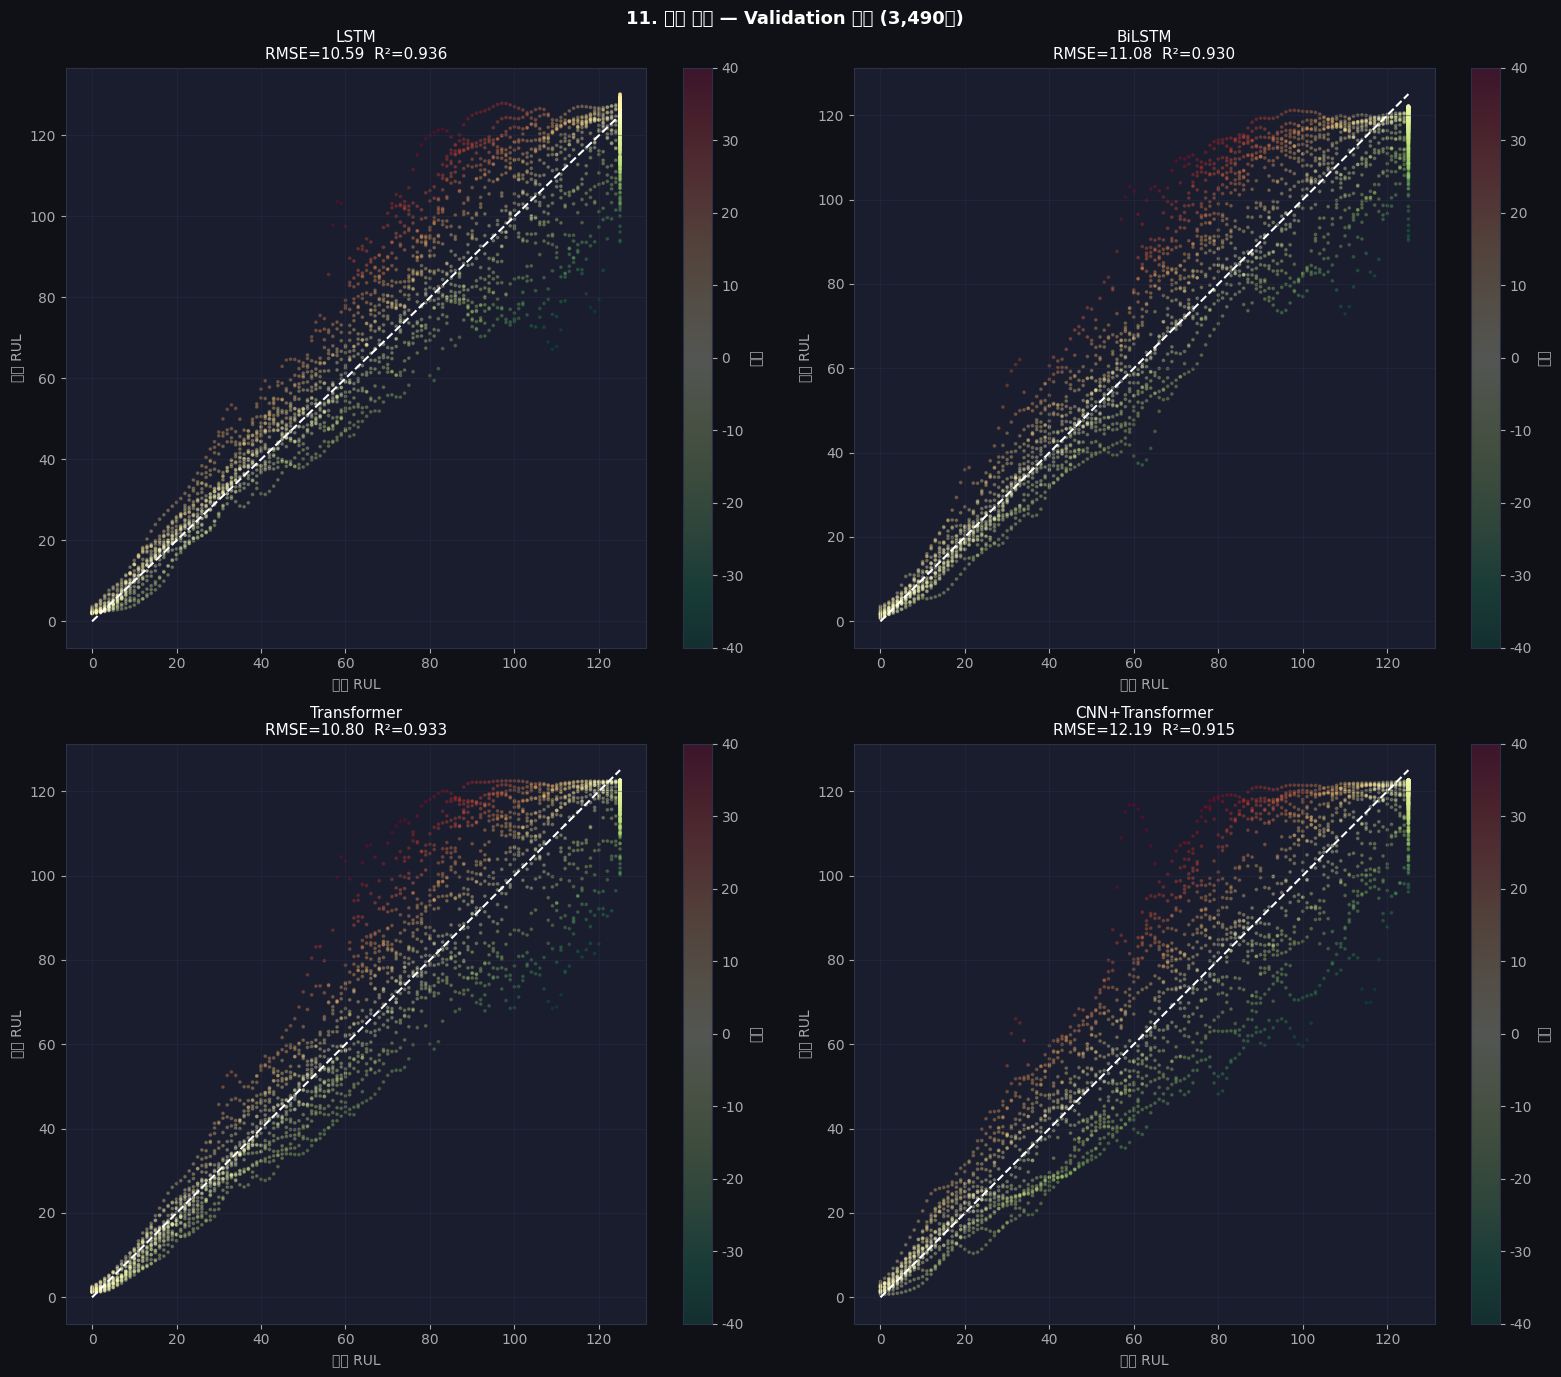

--- 구간별 MAE (Validation) ---


,말기(0~30),중기(31~80),초기(81~125)
모델,,,
LSTM,2.92,8.65,8.04
BiLSTM,2.85,10.06,8.95
Transformer,2.61,9.35,8.32
CNN+Transformer,4.28,12.63,8.55


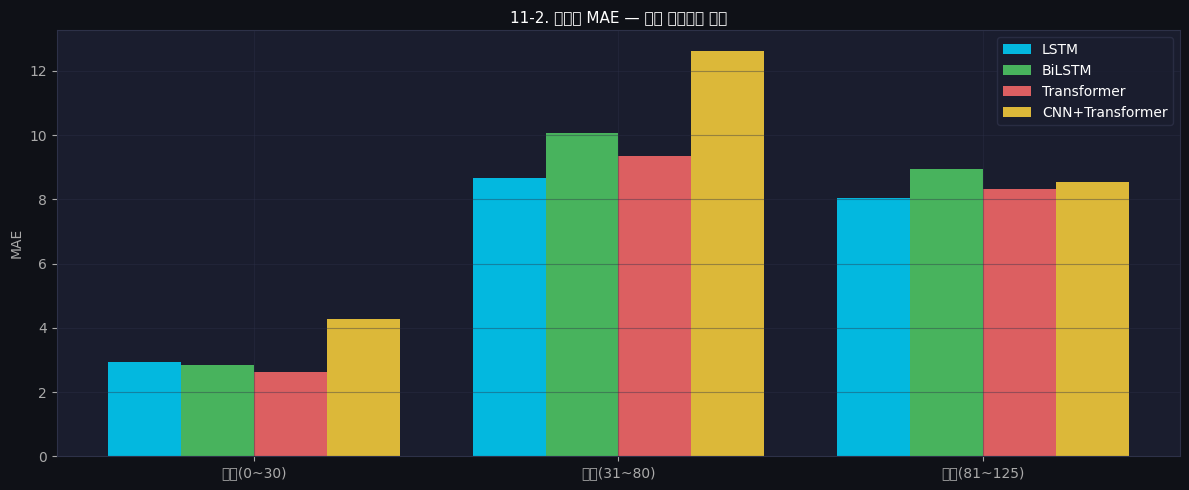

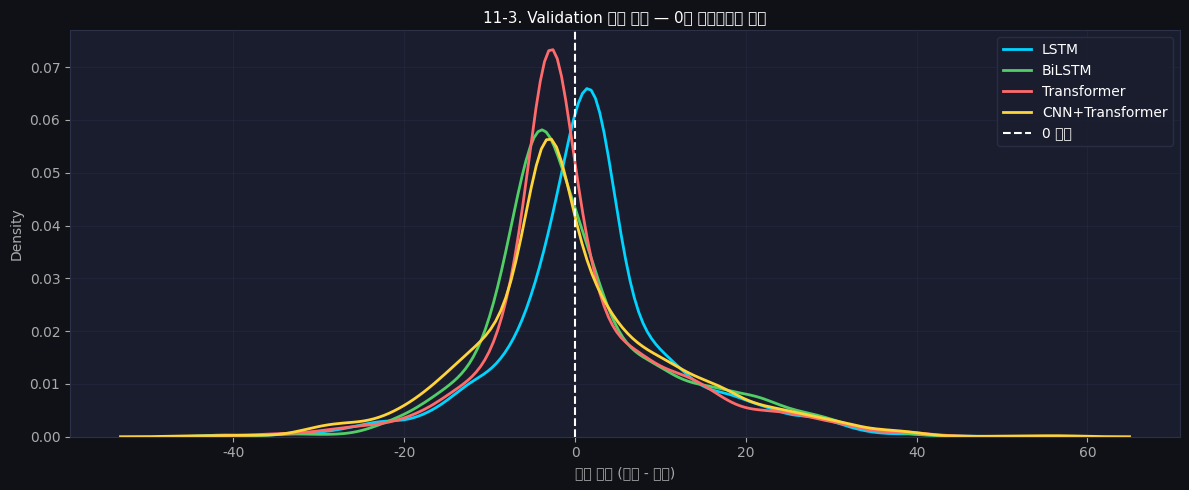

📄 구간별 MAE 저장: results_dl/validation_segment_mae_dl.csv


In [25]:
print('=== 11. 잔차 분석 ===')

# ── Scatter 잔차 (Validation 전체) ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle(f'11. 잔차 분석 — Validation 세트 ({len(y_val):,}행)', fontsize=13, fontweight='bold')

for ax, mname in zip(axes.flat, MODEL_NAMES):
    pred = clip_rul(predict_np(BEST_MODELS[mname], X_val))
    resid = pred - y_val
    sc = ax.scatter(y_val, pred, c=resid, cmap='RdYlGn_r',
                    alpha=0.25, s=3, vmin=-40, vmax=40)
    ax.plot([0, 125], [0, 125], color='white', lw=1.5, ls='--')
    m = get_metrics(y_val, pred)
    ax.set_title(f'{mname}\nRMSE={m["RMSE"]:.2f}  R²={m["R2"]:.3f}')
    ax.set_xlabel('실제 RUL'); ax.set_ylabel('예측 RUL')
    ax.set_facecolor(BG2)
    plt.colorbar(sc, ax=ax, label='잔차')

plt.tight_layout(); plt.show()

# ── 구간별 MAE (말기/중기/초기) ───────────────────────────────────────────────
bins   = [0, 30, 80, 125]
labels = ['말기(0~30)', '중기(31~80)', '초기(81~125)']
rul_cat = pd.cut(y_val, bins=bins, labels=labels)

seg_rows = []
for mname in MODEL_NAMES:
    pred = clip_rul(predict_np(BEST_MODELS[mname], X_val))
    row  = {'모델': mname}
    for seg in labels:
        mask = (rul_cat == seg)
        row[seg] = round(mean_absolute_error(y_val[mask], pred[mask]), 2) if mask.sum() > 0 else np.nan
    seg_rows.append(row)

seg_df = pd.DataFrame(seg_rows).set_index('모델')
print('--- 구간별 MAE (Validation) ---')
display(seg_df.style.background_gradient(cmap='RdYlGn_r').format('{:.2f}'))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(labels)); width = 0.2
for i, mname in enumerate(MODEL_NAMES):
    vals = [seg_df.loc[mname, seg] for seg in labels]
    ax.bar(x + i*width, vals, width, label=mname, color=MODEL_COLORS[mname], alpha=0.85)
ax.set_xticks(x + width*1.5); ax.set_xticklabels(labels)
ax.set_title('11-2. 구간별 MAE — 말기 정확도가 핵심'); ax.set_ylabel('MAE')
ax.legend(); ax.set_facecolor(BG2)
plt.tight_layout(); plt.show()

# ── 오차 KDE ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for mname in MODEL_NAMES:
    pred = clip_rul(predict_np(BEST_MODELS[mname], X_val))
    errs = pred - y_val
    sns.kdeplot(errs, ax=ax, fill=False, lw=2, label=mname, color=MODEL_COLORS[mname])
ax.axvline(0, color='white', lw=1.5, ls='--', label='0 오차')
ax.set_title('11-3. Validation 오차 분포 — 0에 집중될수록 좋음')
ax.set_xlabel('예측 오차 (예측 - 실제)'); ax.legend(); ax.set_facecolor(BG2)
plt.tight_layout(); plt.show()

seg_path = os.path.join(RESULT_DIR, 'validation_segment_mae_dl.csv')
seg_df.to_csv(seg_path, encoding='utf-8-sig')
print(f'📄 구간별 MAE 저장: {seg_path}')


## 12. 모델 해석 — Attention 가중치 & Gradient Saliency

| 해석 방법 | 적용 모델 | 내용 |
|-----------|-----------|------|
| **Gradient Saliency** | LSTM, BiLSTM | 입력 각 timestep×feature에 대한 출력 기울기 → 중요도 |
| **Attention 가중치** | Transformer, CNN+Transformer | 마지막 Encoder 레이어의 self-attention 가중치 시각화 |


=== 12. 모델 해석 ===
대표 샘플 index=10  실제 RUL=0


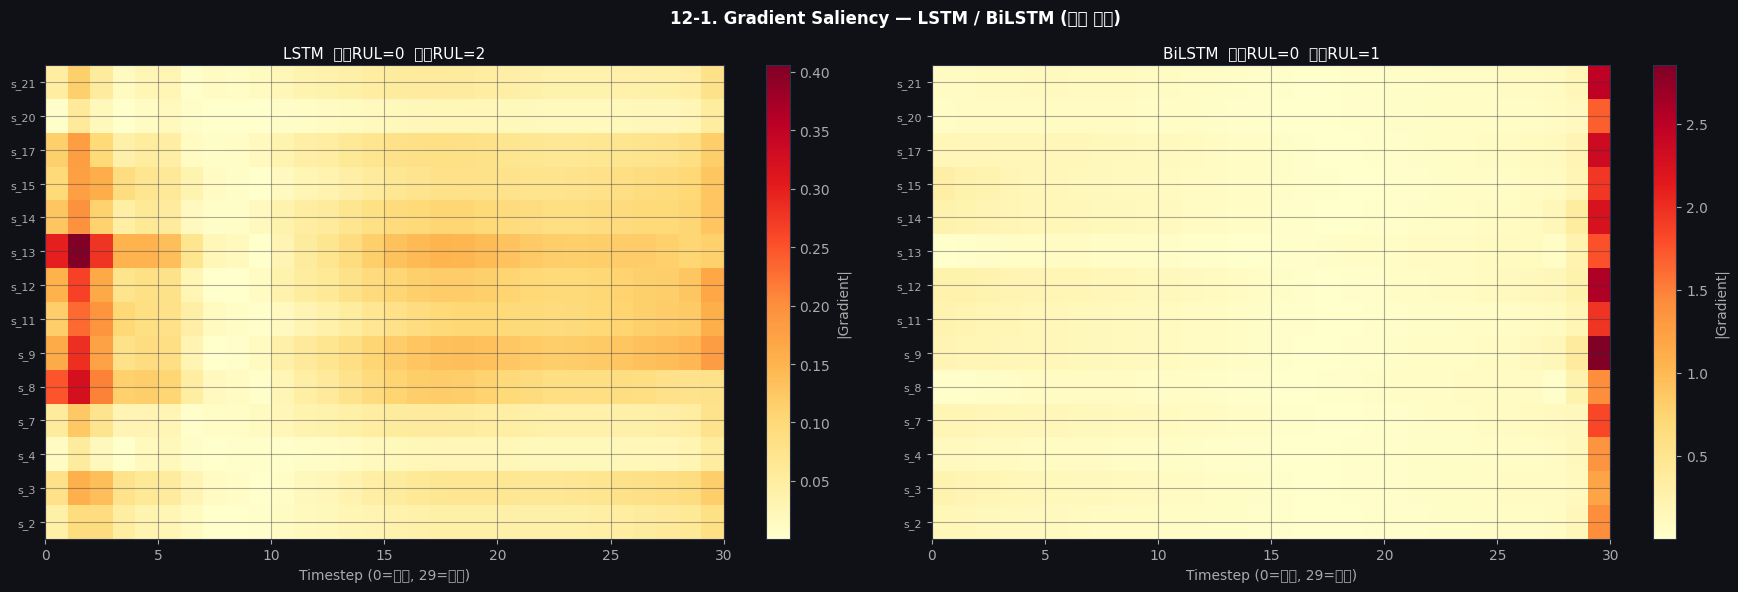

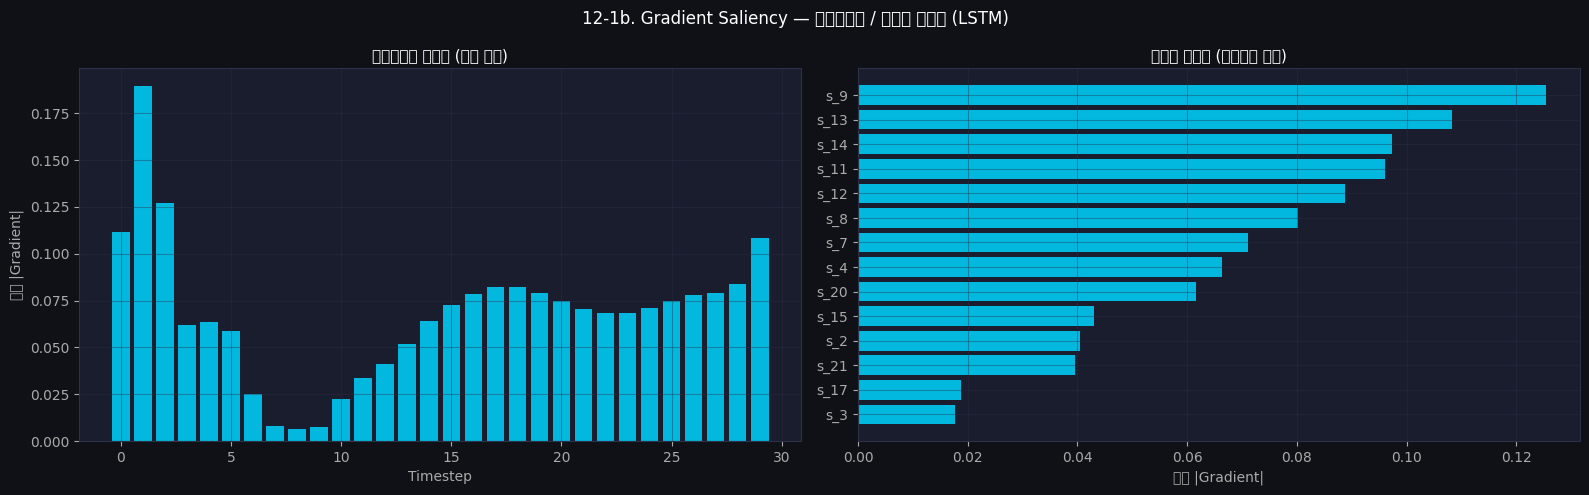

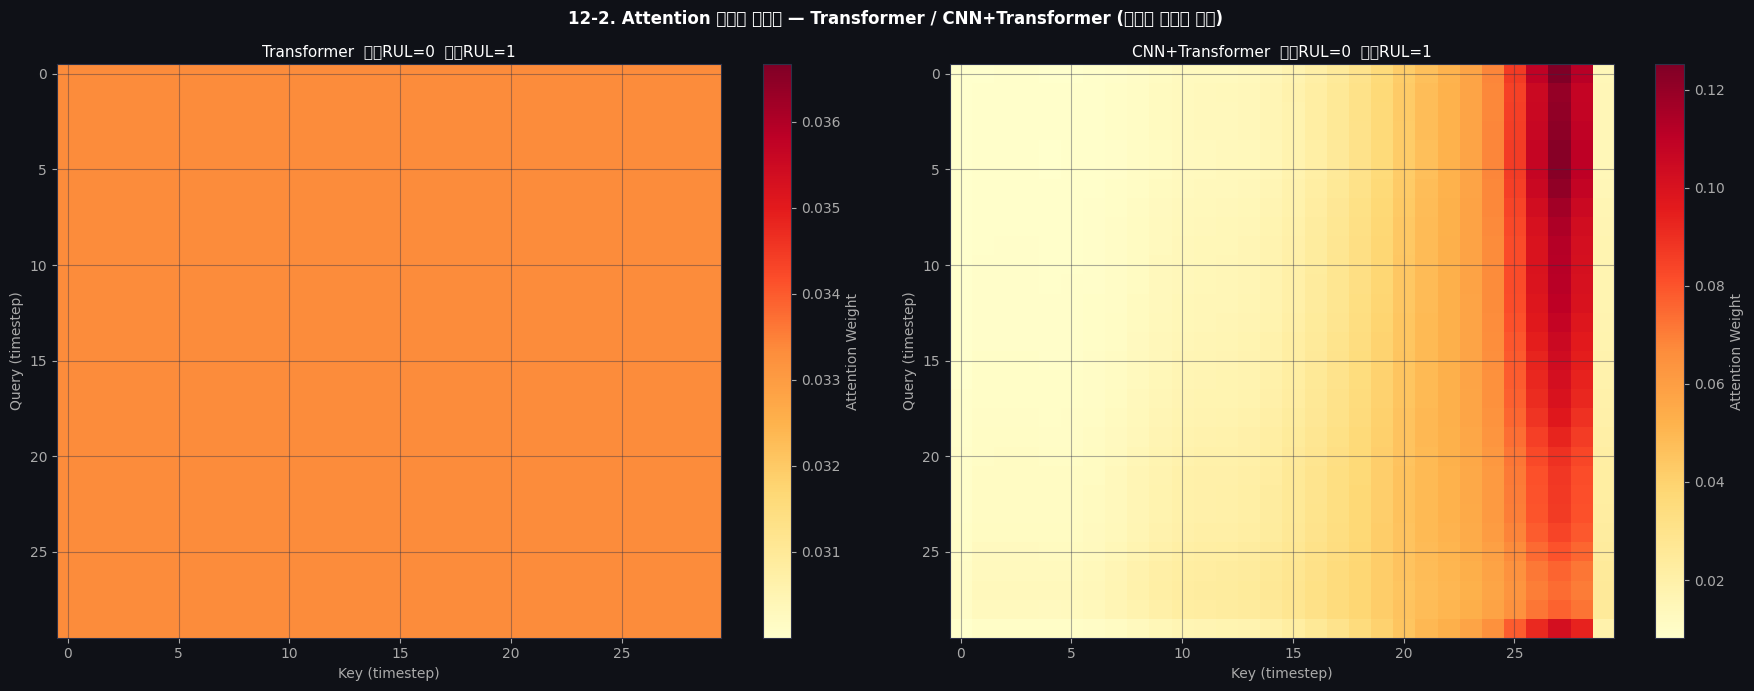

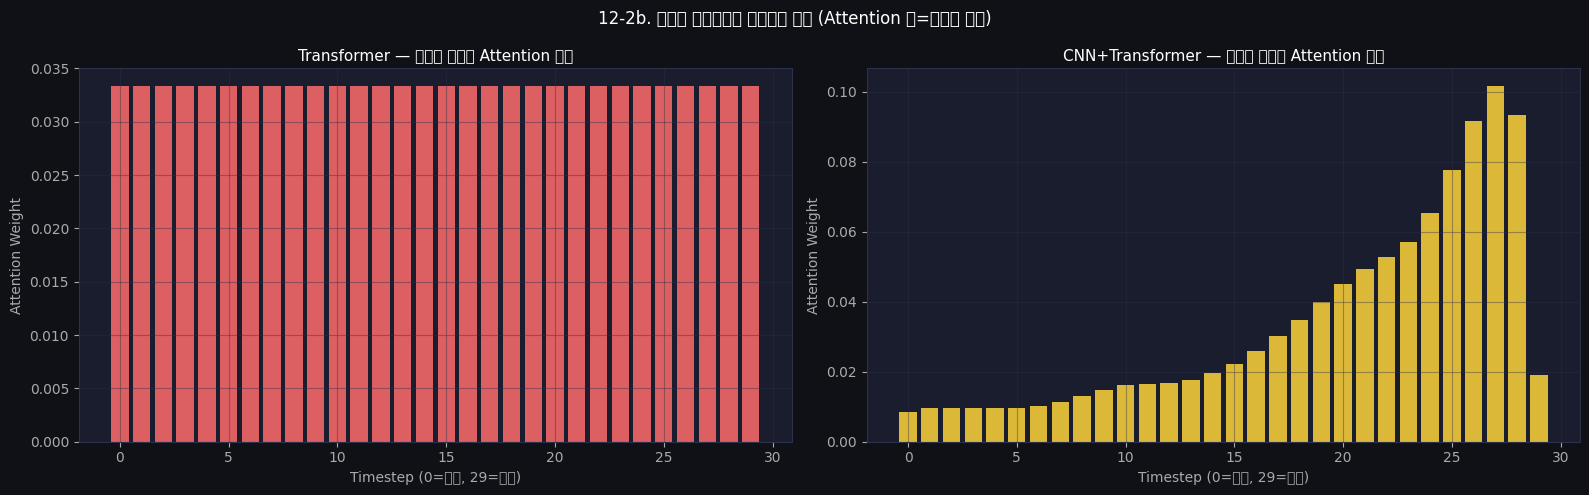

✅ 모델 해석 완료


In [28]:
print('=== 12. 모델 해석 ===')

# ── 공통: 대표 샘플 선택 (val_eval 기준 중간 RUL) ─────────────────────────────
mid_idx = int(np.argsort(y_val_eval)[len(y_val_eval) // 2])
sample_X = torch.tensor(X_val_eval[mid_idx:mid_idx+1], dtype=torch.float32).to(DEVICE)
sample_rul = y_val_eval[mid_idx]
print(f'대표 샘플 index={mid_idx}  실제 RUL={sample_rul:.0f}')

# 모델별 대표 샘플 예측값 미리 계산
sample_preds = {}
for mname, model in BEST_MODELS.items():
    pred_val = clip_rul(predict_np(model, X_val_eval[mid_idx:mid_idx+1]))[0]
    sample_preds[mname] = pred_val


# ─────────────────────────────────────────────────────────────────────────────
# 12-1. Gradient Saliency (LSTM / BiLSTM)
# ─────────────────────────────────────────────────────────────────────────────
def gradient_saliency(model, x_tensor):
    """
    Parameters
    ----------
    model : torch.nn.Module
    x_tensor : torch.Tensor, shape (1, T, F)

    Returns
    -------
    saliency : ndarray, shape (T, F)
        입력에 대한 절대 gradient
    """
    original_training_mode = model.training
    model.eval()  # 해석 시에는 eval 유지

    x = x_tensor.clone().detach().requires_grad_(True)

    # 기존 gradient 정리
    model.zero_grad(set_to_none=True)

    # cuDNN RNN backward 에러 방지를 위해 해당 구간만 비활성화
    with torch.backends.cudnn.flags(enabled=False):
        pred = model(x)              # shape: (1,) or (1,1)
        pred.sum().backward()

    saliency = x.grad.abs().squeeze(0).detach().cpu().numpy()

    # 원래 상태 복원
    if original_training_mode:
        model.train()

    return saliency


fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('12-1. Gradient Saliency — LSTM / BiLSTM (대표 샘플)', fontsize=12, fontweight='bold')

for ax, mname in zip(axes, ['LSTM', 'BiLSTM']):
    sal = gradient_saliency(BEST_MODELS[mname], sample_X)  # (T, F)

    im = ax.imshow(
        sal.T,
        aspect='auto',
        cmap='YlOrRd',
        extent=[0, WINDOW_SIZE, -0.5, N_FEATURES - 0.5]
    )
    ax.set_yticks(range(N_FEATURES))
    ax.set_yticklabels(DL_FEATURES, fontsize=8)
    ax.set_xlabel('Timestep (0=과거, 29=현재)')
    ax.set_title(
        f'{mname}  실제RUL={sample_rul:.0f}  예측RUL={sample_preds[mname]:.0f}'
    )
    plt.colorbar(im, ax=ax, label='|Gradient|')
    ax.set_facecolor(BG2)

plt.tight_layout()
plt.show()


# ── 타임스텝별 중요도 / 피처별 중요도 (LSTM) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('12-1b. Gradient Saliency — 타임스텝별 / 피처별 중요도 (LSTM)', fontsize=12)

sal_lstm = gradient_saliency(BEST_MODELS['LSTM'], sample_X)

# 타임스텝별 중요도
axes[0].bar(
    range(WINDOW_SIZE),
    sal_lstm.mean(axis=1),
    color=MODEL_COLORS['LSTM'],
    alpha=0.85
)
axes[0].set_xlabel('Timestep')
axes[0].set_ylabel('평균 |Gradient|')
axes[0].set_title('타임스텝별 중요도 (피처 평균)')
axes[0].set_facecolor(BG2)

# 피처별 중요도
feat_imp = sal_lstm.mean(axis=0)
order = np.argsort(feat_imp)[::-1]

axes[1].barh(
    [DL_FEATURES[i] for i in order[::-1]],
    feat_imp[order[::-1]],
    color=MODEL_COLORS['LSTM'],
    alpha=0.85
)
axes[1].set_xlabel('평균 |Gradient|')
axes[1].set_title('피처별 중요도 (타임스텝 평균)')
axes[1].set_facecolor(BG2)

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 12-2. Attention 가중치 (Transformer / CNN+Transformer)
# ─────────────────────────────────────────────────────────────────────────────
def get_attention_weights(model, x_tensor):
    """
    마지막 Transformer encoder layer의 self-attention weight 추출

    Returns
    -------
    attn : ndarray, shape (nhead, T, T) or None
    """
    original_training_mode = model.training
    model.eval()

    attn_result = None

    try:
        with torch.no_grad():
            # 입력 임베딩/전처리
            if hasattr(model, 'input_proj'):
                x = model.input_proj(x_tensor)
                if hasattr(model, 'pos_enc'):
                    x = model.pos_enc(x)

            elif hasattr(model, 'cnn'):
                x = model.cnn(x_tensor.permute(0, 2, 1)).permute(0, 2, 1)
                if hasattr(model, 'pos_enc'):
                    x = model.pos_enc(x)
            else:
                x = x_tensor

            layers = list(model.encoder.layers)
            if len(layers) == 0:
                return None

            # 마지막 전 레이어까지 먼저 통과
            for layer in layers[:-1]:
                x = layer(x)

            last_layer = layers[-1]

            # 마지막 레이어에서 self-attention만 직접 추출
            if getattr(last_layer, 'norm_first', False):
                q = last_layer.norm1(x)
            else:
                q = x

            attn_out, attn_w = last_layer.self_attn(
                q, q, q,
                need_weights=True,
                average_attn_weights=False
            )

            # attn_w shape:
            # (batch, nhead, T, T)  또는 구현에 따라 유사 형태
            attn_w = attn_w.detach().cpu()

            if attn_w.dim() == 4:
                attn_result = attn_w.squeeze(0).numpy()   # (nhead, T, T)
            elif attn_w.dim() == 3:
                attn_result = attn_w.numpy()              # (nhead, T, T) 가능
            else:
                attn_result = None

    except Exception as e:
        print(f'[Attention 추출 오류] {type(e).__name__}: {e}')
        attn_result = None

    finally:
        if original_training_mode:
            model.train()

    return attn_result


fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    '12-2. Attention 가중치 히트맵 — Transformer / CNN+Transformer (마지막 레이어 평균)',
    fontsize=12,
    fontweight='bold'
)

for ax, mname in zip(axes, ['Transformer', 'CNN+Transformer']):
    attn = get_attention_weights(BEST_MODELS[mname], sample_X)

    if attn is not None:
        attn_mean = attn.mean(axis=0)  # (T, T) : head 평균

        im = ax.imshow(attn_mean, cmap='YlOrRd', aspect='auto')
        ax.set_xlabel('Key (timestep)')
        ax.set_ylabel('Query (timestep)')
        ax.set_title(
            f'{mname}  실제RUL={sample_rul:.0f}  예측RUL={sample_preds[mname]:.0f}'
        )
        plt.colorbar(im, ax=ax, label='Attention Weight')
        ax.set_facecolor(BG2)

    else:
        ax.text(
            0.5, 0.5,
            'Attention 추출 실패\n(모델 구조 확인 필요)',
            ha='center', va='center',
            transform=ax.transAxes,
            color=WHITE
        )
        ax.set_facecolor(BG2)

plt.tight_layout()
plt.show()


# ── 마지막 타임스텝이 받는 attention (query=마지막, key=전체) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('12-2b. 마지막 타임스텝이 주목하는 구간 (Attention 행=마지막 토큰)', fontsize=12)

for ax, mname in zip(axes, ['Transformer', 'CNN+Transformer']):
    attn = get_attention_weights(BEST_MODELS[mname], sample_X)

    if attn is not None:
        last_row = attn.mean(axis=0)[-1, :]   # 마지막 query가 각 key에 주는 attention

        ax.bar(
            range(WINDOW_SIZE),
            last_row,
            color=MODEL_COLORS[mname],
            alpha=0.85
        )
        ax.set_xlabel('Timestep (0=과거, 29=현재)')
        ax.set_ylabel('Attention Weight')
        ax.set_title(f'{mname} — 마지막 토큰의 Attention 분포')
        ax.set_facecolor(BG2)
    else:
        ax.text(
            0.5, 0.5,
            'Attention 추출 실패',
            ha='center', va='center',
            transform=ax.transAxes,
            color=WHITE
        )
        ax.set_facecolor(BG2)

plt.tight_layout()
plt.show()

print('✅ 모델 해석 완료')

## 13. 엔진별 RUL 예측 곡선 — Validation 대표 엔진

=== 13. 엔진별 RUL 예측 곡선 ===


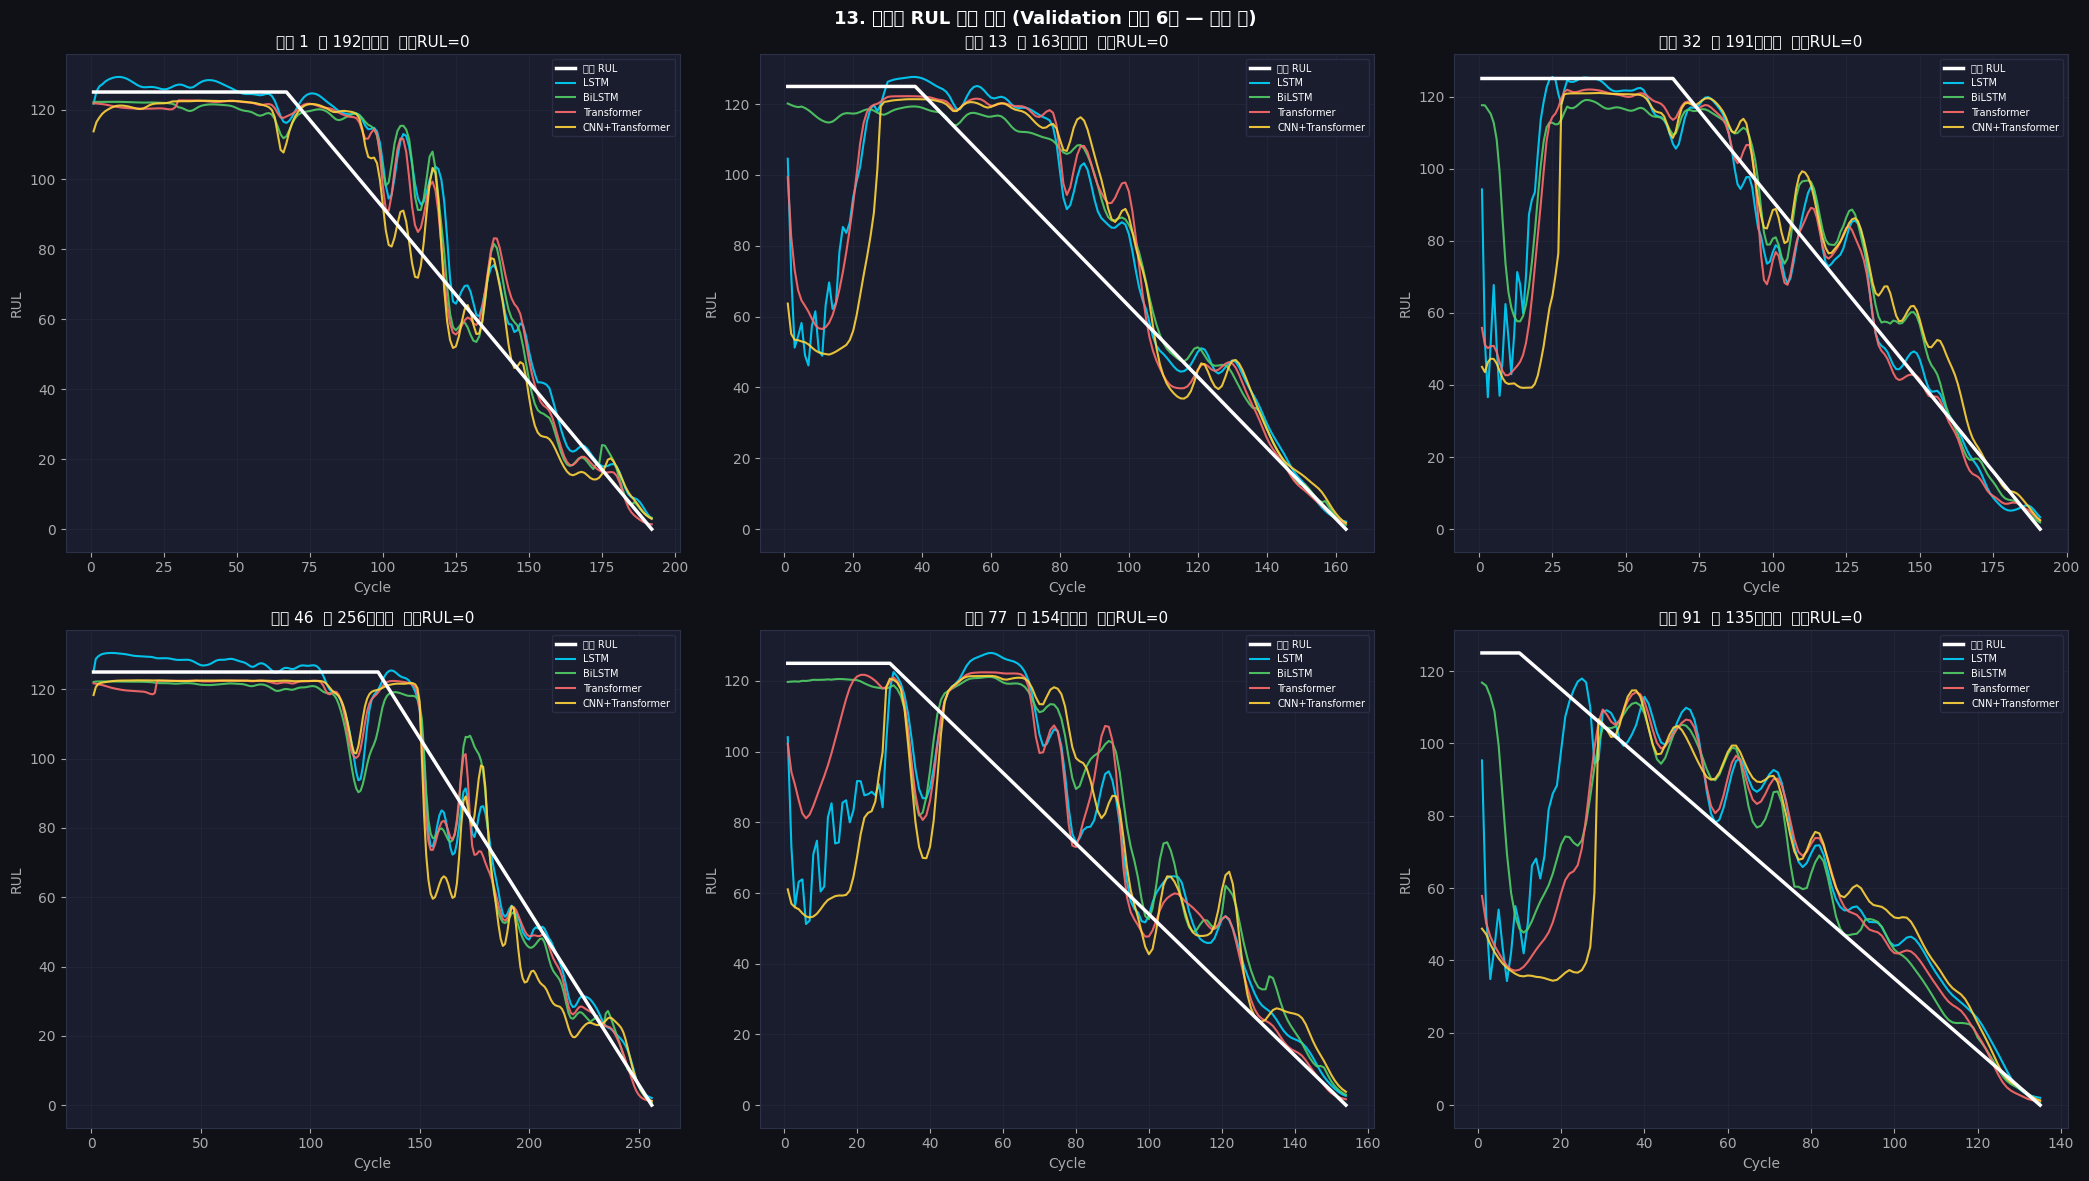

✅ 엔진별 RUL 예측 곡선 완료


In [29]:
print('=== 13. 엔진별 RUL 예측 곡선 ===')

# val_eval 엔진 중 수명 순으로 대표 6대 선택
rul_sort = np.argsort(y_val_eval)
n_sel = min(6, len(val_eval_units))
sel_indices = np.linspace(0, len(rul_sort)-1, n_sel, dtype=int)
sel_units = val_eval_units[rul_sort[sel_indices]]

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle('13. 엔진별 RUL 예측 곡선 (Validation 대표 6대 — 수명 순)', fontsize=13, fontweight='bold')

for ax, uid in zip(axes.flat, sel_units):
    udf  = valid_ml[valid_ml['unit_nr'] == uid].sort_values('time_cycles').reset_index(drop=True)
    n    = len(udf)
    true_rul = udf['RUL'].values

    # 각 사이클마다 예측: 가장 최근 WINDOW_SIZE 사이클 슬라이딩
    preds_all = {m: [] for m in MODEL_NAMES}
    for t in range(n):
        start = max(0, t - WINDOW_SIZE + 1)
        seg   = udf[DL_FEATURES].values[start:t+1].astype(np.float32)
        if len(seg) < WINDOW_SIZE:
            pad = np.zeros((WINDOW_SIZE - len(seg), N_FEATURES), dtype=np.float32)
            seg = np.vstack([pad, seg])
        x_t = seg[np.newaxis]  # (1, W, F)
        for m in MODEL_NAMES:
            preds_all[m].append(float(clip_rul(predict_np(BEST_MODELS[m], x_t))[0]))

    ax.plot(udf['time_cycles'], true_rul, color='white', lw=2.5, label='실제 RUL', zorder=5)
    for m in MODEL_NAMES:
        ax.plot(udf['time_cycles'], preds_all[m], color=MODEL_COLORS[m],
                lw=1.5, alpha=0.9, label=m)
    ax.set_title(f'엔진 {uid}  총 {n}사이클  실제RUL={true_rul[-1]:.0f}')
    ax.set_xlabel('Cycle'); ax.set_ylabel('RUL')
    ax.legend(loc='upper right', fontsize=7); ax.set_facecolor(BG2)

plt.tight_layout(); plt.show()
print('✅ 엔진별 RUL 예측 곡선 완료')


## 14. NASA Score 상세 분석

=== 14. NASA Score 상세 분석 ===


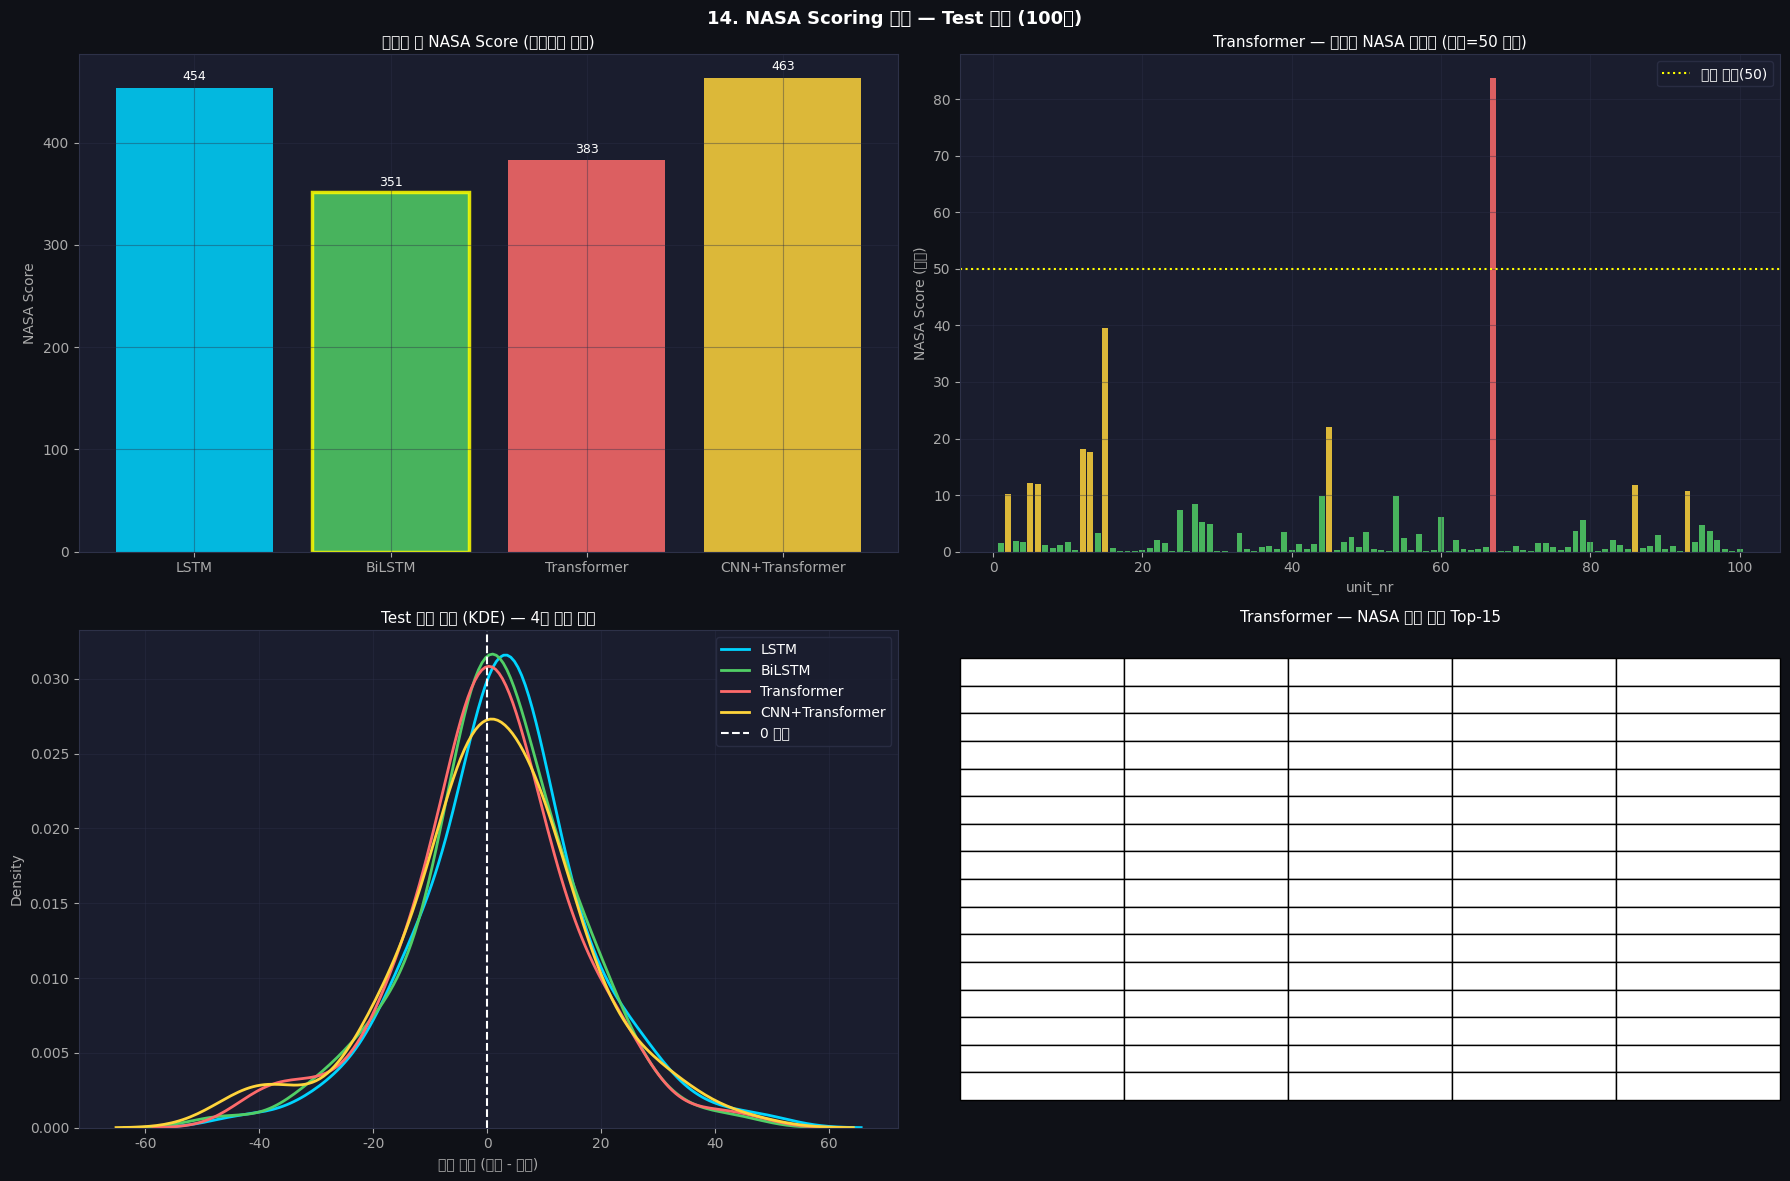

📄 NASA 위험 엔진 저장: results_dl/nasa_risk_engines_dl.csv

--- DL 모델 성능 요약 ---
  LSTM                : Test RMSE=14.863  Test NASA=  453.7  Val NASA(eval)=    5.4
  BiLSTM              : Test RMSE=14.353  Test NASA=  351.4  Val NASA(eval)=    4.1
  Transformer         : Test RMSE=14.895  Test NASA=  383.4  Val NASA(eval)=    3.8
  CNN+Transformer     : Test RMSE=16.157  Test NASA=  463.1  Val NASA(eval)=    4.5


In [30]:
print('=== 14. NASA Score 상세 분석 ===')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('14. NASA Scoring 분석 — Test 세트 (100대)', fontsize=13, fontweight='bold')

# ── 모델별 총 NASA Score ─────────────────────────────────────────────────────
ax = axes[0, 0]
scores = {m: ALL_RESULTS[m]['test_metrics']['NASA_Score'] for m in MODEL_NAMES}
bars   = ax.bar(scores.keys(), scores.values(),
                color=[MODEL_COLORS[m] for m in scores], alpha=0.85)
ax.set_title('모델별 총 NASA Score (낮을수록 좋음)')
ax.set_ylabel('NASA Score')
best_i = np.argmin(list(scores.values()))
list(bars)[best_i].set_edgecolor('yellow'); list(bars)[best_i].set_linewidth(2.5)
for bar, v in zip(bars, scores.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f'{v:,.0f}', ha='center', va='bottom', fontsize=9, color=WHITE)
ax.set_facecolor(BG2)

# ── 최고 모델 엔진별 기여도 ──────────────────────────────────────────────────
ax = axes[0, 1]
pred_best = test_pred_all[best_model_name]
d = pred_best - y_test
per_ns = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
colors_ns = [C[1] if v > 50 else (C[3] if v > 10 else C[2]) for v in per_ns]
ax.bar(np.arange(1, len(per_ns)+1), per_ns, color=colors_ns, alpha=0.85)
ax.axhline(50, color='yellow', lw=1.5, ls=':', label='위험 기준(50)')
ax.set_title(f'{best_model_name} — 엔진별 NASA 기여도 (빨강=50 초과)')
ax.set_xlabel('unit_nr'); ax.set_ylabel('NASA Score (개별)')
ax.legend(); ax.set_facecolor(BG2)

# ── 오차 분포 비교 (KDE) ─────────────────────────────────────────────────────
ax = axes[1, 0]
for m in MODEL_NAMES:
    errs = test_pred_all[m] - y_test
    sns.kdeplot(errs, ax=ax, lw=2, label=m, color=MODEL_COLORS[m])
ax.axvline(0, color='white', lw=1.5, ls='--', label='0 오차')
ax.set_title('Test 오차 분포 (KDE) — 4개 모델 비교')
ax.set_xlabel('예측 오차 (예측 - 실제)')
ax.legend(); ax.set_facecolor(BG2)

# ── NASA 위험 엔진 Top-15 표 ─────────────────────────────────────────────────
ax = axes[1, 1]
risk_df = pd.DataFrame({
    'unit': np.arange(1, len(y_test)+1),
    'actual_rul': y_test.astype(int),
    'pred_rul': np.round(pred_best, 1),
    'error': np.round(d, 1),
    'nasa': np.round(per_ns, 1),
}).sort_values('nasa', ascending=False).head(15)

ax.axis('off')
tbl = ax.table(cellText=risk_df.values, colLabels=risk_df.columns, loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.4)
ax.set_title(f'{best_model_name} — NASA 위험 엔진 Top-15')

plt.tight_layout(); plt.show()

risk_path = os.path.join(RESULT_DIR, 'nasa_risk_engines_dl.csv')
risk_df.to_csv(risk_path, index=False, encoding='utf-8-sig')
print(f'📄 NASA 위험 엔진 저장: {risk_path}')

# ── ML vs DL 비교 안내 ────────────────────────────────────────────────────────
print('\n--- DL 모델 성능 요약 ---')
for mname in MODEL_NAMES:
    res = ALL_RESULTS[mname]
    print(f'  {mname:20s}: Test RMSE={res["test_metrics"]["RMSE"]:.3f}  '
          f'Test NASA={res["test_metrics"]["NASA_Score"]:7.1f}  '
          f'Val NASA(eval)={res["val_eval_nasa"]:7.1f}')


## 15. 모델 및 산출물 저장

In [31]:
print('=== 15. 모델 및 산출물 저장 ===')

# ── PyTorch 모델 저장 ─────────────────────────────────────────────────────────
for mname, model in BEST_MODELS.items():
    state_path = os.path.join(MODEL_DIR, f'FD001_{mname}_best.pt')
    arch_path  = os.path.join(MODEL_DIR, f'FD001_{mname}_arch.json')
    torch.save(model.state_dict(), state_path)
    with open(arch_path, 'w') as f:
        json.dump(ALL_RESULTS[mname]['params'], f, indent=2)
    size_kb = os.path.getsize(state_path) / 1024
    print(f'  저장: {state_path} ({size_kb:.1f} KB)')

# ── 요약 JSON ─────────────────────────────────────────────────────────────────
summary = {
    'best_model'       : best_model_name,
    'selection_rule'   : 'Val NASA(eval) → Val RMSE',
    'random_state'     : RANDOM_STATE,
    'window_size'      : WINDOW_SIZE,
    'n_features'       : N_FEATURES,
    'dl_features'      : DL_FEATURES,
    'models'           : {
        m: {
            'params'         : ALL_RESULTS[m]['params'],
            'n_params'       : ALL_RESULTS[m]['n_params'],
            'best_epoch'     : ALL_RESULTS[m]['best_epoch'],
            'val_eval_nasa'  : round(ALL_RESULTS[m]['val_eval_nasa'], 1),
            'val_metrics'    : {k: round(v, 4) for k, v in ALL_RESULTS[m]['val_metrics'].items()},
            'test_metrics'   : {k: round(v, 4) for k, v in ALL_RESULTS[m]['test_metrics'].items()},
            'fit_seconds'    : round(ALL_RESULTS[m]['fit_seconds'], 1),
        }
        for m in MODEL_NAMES
    }
}
summary_path = os.path.join(RESULT_DIR, 'best_model_summary_dl.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

# ── MLflow 아티팩트 업로드 ────────────────────────────────────────────────────
if mlflow.active_run() is not None:
    for p in [result_csv_path, test_detail_path, seg_path, risk_path, summary_path]:
        if os.path.exists(p):
            mlflow.log_artifact(p)
    mlflow.log_params({'best_model': best_model_name})
    mlflow.end_run()
    print('✅ MLflow 부모 run 종료')

print(f'\n✅ 저장 완료')
print(f'  모델 폴더   : {os.path.abspath(MODEL_DIR)}')
print(f'  결과 폴더   : {os.path.abspath(RESULT_DIR)}')
print(f'  MLflow 폴더 : {os.path.abspath(MLFLOW_DIR)}')


=== 15. 모델 및 산출물 저장 ===
  저장: models_dl/FD001_LSTM_best.pt (872.5 KB)
  저장: models_dl/FD001_BiLSTM_best.pt (3733.4 KB)
  저장: models_dl/FD001_Transformer_best.pt (552.9 KB)
  저장: models_dl/FD001_CNN+Transformer_best.pt (666.5 KB)
✅ MLflow 부모 run 종료

✅ 저장 완료
  모델 폴더   : /content/models_dl
  결과 폴더   : /content/results_dl
  MLflow 폴더 : /content/mlruns


## 16. 최종 요약 리포트

In [32]:
print('=' * 90)
print(' NASA C-MAPSS FD001 — 딥러닝 최종 요약 (LSTM / BiLSTM / Transformer / CNN+Transformer)')
print('=' * 90)

print('\n[데이터]')
print(f'  Sub-train   : {len(X_sub):,}개 윈도우 (엔진 {valid_ml["unit_nr"].nunique()}대 제외 나머지)')
print(f'  Validation  : {len(X_val):,}개 윈도우')
print(f'  Val-eval    : {len(X_val_eval)}개 (엔진별 마지막 윈도우 — NASA Score 기준)')
print(f'  Test        : {len(X_test)}개 (엔진 100대 마지막 윈도우)')
print(f'  피처 수     : {N_FEATURES}개  |  Window: {WINDOW_SIZE}사이클  |  Step: 1')

print('\n[모델 선택 기준]')
print('  1) Val NASA Score — 엔진별 마지막 윈도우 기준 (Test와 동일한 방식)')
print('  2) Val RMSE (동률 시 보조)')
print('  ※ Test는 최종 확인용이며 모델 선택에 사용하지 않음')

print('\n[최종 순위 — Val NASA(eval) 기준]')
rank_view = result_df[['선정순위','모델','Val NASA(eval)','Val RMSE',
                        'Test NASA','Test RMSE','파라미터 수','학습시간(초)']]
display(rank_view)

print(f'\n[🏆 최고 모델] {best_model_name}')
bm = ALL_RESULTS[best_model_name]
print(f'  최적 파라미터      : {bm["params"]}')
print(f'  파라미터 수        : {bm["n_params"]:,}')
print(f'  Best Epoch         : {bm["best_epoch"]}')
print(f'  Val NASA(eval)     : {bm["val_eval_nasa"]:.1f}')
print(f'  Validation (full)  : RMSE={bm["val_metrics"]["RMSE"]:.3f}  '
      f'MAE={bm["val_metrics"]["MAE"]:.3f}  R²={bm["val_metrics"]["R2"]:.4f}')
print(f'  Test               : RMSE={bm["test_metrics"]["RMSE"]:.3f}  '
      f'MAE={bm["test_metrics"]["MAE"]:.3f}  R²={bm["test_metrics"]["R2"]:.4f}  '
      f'NASA={bm["test_metrics"]["NASA_Score"]:.1f}')

print('\n[모델별 주요 특성 비교]')
char_df = pd.DataFrame({
    '모델'       : ['LSTM', 'BiLSTM', 'Transformer', 'CNN+Transformer'],
    '순방향'     : ['✓', '✓', '✓', '✓'],
    '역방향'     : ['✗', '✓', '✗', '✗'],
    'Attention'  : ['✗', '✗', '✓', '✓'],
    'CNN 국소패턴': ['✗', '✗', '✗', '✓'],
    '파라미터 수': [f'{ALL_RESULTS[m]["n_params"]:,}' for m in
                  ['LSTM','BiLSTM','Transformer','CNN+Transformer']],
}).set_index('모델')
display(char_df)

print('\n[MLflow 활용]')
print(f'  Tracking URI : {mlflow.get_tracking_uri()}')
print(f'  Experiment   : {EXPERIMENT_NAME}')
print('  기록 항목     : 파라미터 / Val·Test 메트릭 / 모델 .pt / CSV 아티팩트')

print('\n[다음 단계 추천]')
print('  1. ML 노트북 결과와 DL 결과 직접 RMSE / NASA Score 비교 정리')
print('  2. GRU / TCN / Mamba 등 추가 아키텍처 실험')
print('  3. FD002~FD004 확장 (다중 조건 / 다중 결함)')
print('  4. 앙상블: 최고 DL + 최고 ML 예측 평균')
print('  5. 온라인 추론 파이프라인: scaler.pkl + best .pt → TorchScript export')
print('=' * 90)


 NASA C-MAPSS FD001 — 딥러닝 최종 요약 (LSTM / BiLSTM / Transformer / CNN+Transformer)

[데이터]
  Sub-train   : 14,241개 윈도우 (엔진 20대 제외 나머지)
  Validation  : 3,490개 윈도우
  Val-eval    : 20개 (엔진별 마지막 윈도우 — NASA Score 기준)
  Test        : 100개 (엔진 100대 마지막 윈도우)
  피처 수     : 14개  |  Window: 30사이클  |  Step: 1

[모델 선택 기준]
  1) Val NASA Score — 엔진별 마지막 윈도우 기준 (Test와 동일한 방식)
  2) Val RMSE (동률 시 보조)
  ※ Test는 최종 확인용이며 모델 선택에 사용하지 않음

[최종 순위 — Val NASA(eval) 기준]


,선정순위,모델,Val NASA(eval),Val RMSE,Test NASA,Test RMSE,파라미터 수,학습시간(초)
0,1,Transformer,3.8,10.799,383.4,14.895,"104,065",33.9
1,2,BiLSTM,4.1,11.076,351.4,14.353,"954,497",93.5
2,3,CNN+Transformer,4.5,12.193,463.1,16.157,"132,993",18.9
3,4,LSTM,5.4,10.590,453.7,14.863,"222,465",18.4



[🏆 최고 모델] Transformer
  최적 파라미터      : {'d_model': 64, 'nhead': 4, 'num_layers': 4, 'dim_feedforward': 64, 'dropout': 0.10285120945841107, 'lr': 0.001969030963380924, 'weight_decay': 7.692749611389408e-05}
  파라미터 수        : 104,065
  Best Epoch         : 26
  Val NASA(eval)     : 3.8
  Validation (full)  : RMSE=10.799  MAE=7.594  R²=0.9331
  Test               : RMSE=14.895  MAE=10.919  R²=0.8715  NASA=383.4

[모델별 주요 특성 비교]


,순방향,역방향,Attention,CNN 국소패턴,파라미터 수
모델,,,,,
LSTM,✓,✗,✗,✗,"222,465"
BiLSTM,✓,✓,✗,✗,"954,497"
Transformer,✓,✗,✓,✗,"104,065"
CNN+Transformer,✓,✗,✓,✓,"132,993"



[MLflow 활용]
  Tracking URI : file:///content/mlruns
  Experiment   : CMAPSS_FD001_DL
  기록 항목     : 파라미터 / Val·Test 메트릭 / 모델 .pt / CSV 아티팩트

[다음 단계 추천]
  1. ML 노트북 결과와 DL 결과 직접 RMSE / NASA Score 비교 정리
  2. GRU / TCN / Mamba 등 추가 아키텍처 실험
  3. FD002~FD004 확장 (다중 조건 / 다중 결함)
  4. 앙상블: 최고 DL + 최고 ML 예측 평균
  5. 온라인 추론 파이프라인: scaler.pkl + best .pt → TorchScript export
